In [1]:
import sys
import os

sys.path.append(os.path.abspath('..'))

from helpers.mysql_connections import create_mysql_engine

import pandas as pd
import matplotlib.pyplot as plt

engine = create_mysql_engine()

templates_query = 'SELECT * FROM gophish.templates;'
df_templates = pd.read_sql( templates_query, engine )
df_templates.head(10)

,id,user_id,name,subject,text,html,modified_date,envelope_sender
0,1,1,Verificacion de acceso institucional,Verificacion urgente de acceso institucional,Asunto: Verificacion urgente de acceso institu...,<html><body>\n <p><strong>Verificacion urge...,2021-05-23 10:21:55,None
1,2,1,Entrega retenida por direccion incompleta,Entrega retenida - accion requerida,Asunto: Entrega retenida - accion requerida\n\...,<html><body>\n <p><strong>Entrega retenida ...,2024-11-05 22:26:04,None
2,3,1,Actividad financiera inusual,Actividad inusual detectada en su perfil,Asunto: Actividad inusual detectada en su perf...,<html><body>\n <p><strong>Actividad inusual...,2021-06-03 01:15:43,None
3,4,1,Actualizacion de VPN corporativa,Accion requerida: actualizacion de VPN corpora...,Asunto: Accion requerida: actualizacion de VPN...,<html><body>\n <p><strong>Accion requerida:...,2025-01-03 16:30:06,None
4,5,1,Revision de documento compartido,Documento compartido requiere revision inmediata,Asunto: Documento compartido requiere revision...,<html><body>\n <p><strong>Documento compart...,2024-05-10 03:31:55,None
5,6,1,Actualizacion de recursos humanos,Confirmacion obligatoria de datos laborales,Asunto: Confirmacion obligatoria de datos labo...,<html><body>\n <p><strong>Confirmacion obli...,2024-12-17 23:30:34,None
6,7,1,Notificacion de factura pendiente,Factura pendiente de validacion,Asunto: Factura pendiente de validacion\n\nEst...,<html><body>\n <p><strong>Factura pendiente...,2022-05-10 07:17:41,None
7,8,1,Migracion de almacenamiento,Restablecimiento de acceso a almacenamiento en...,Asunto: Restablecimiento de acceso a almacenam...,<html><body>\n <p><strong>Restablecimiento ...,2022-11-08 17:21:33,None
8,9,1,Suspension de buzon,Su buzon excedio el limite permitido,Asunto: Su buzon excedio el limite permitido\n...,<html><body>\n <p><strong>Su buzon excedio ...,2023-02-23 15:32:59,None
9,10,1,Beneficio interno no reclamado,Tiene un beneficio interno pendiente de confir...,Asunto: Tiene un beneficio interno pendiente d...,<html><body>\n <p><strong>Tiene un benefici...,2022-01-16 10:46:17,None


Revision de la estructura de las tablas de principal interes

In [2]:
import sys
import os

sys.path.append(os.path.abspath('..'))

from helpers.mysql_connections import create_mysql_engine

engine = create_mysql_engine()

import pandas as pd

tables = [
    "campaigns",
    "results",
    "email_requests",
    "mail_logs",
    "events",
    "templates",
    "pages",
    "smtp",
    "targets",
    "groups",
    "group_targets",
    "headers",
    "text_clasification"
]

for table in tables:
    try:
        df = pd.read_sql(f"SELECT * FROM {table} LIMIT 5", engine)
        print(f"\nTABLA: {table}")
        print("columnas:", list(df.columns))
        print("filas ejemplo:", len(df))
        print(df.head(2))
    except Exception as e:
        print(f"\nTABLA: {table}")
        print("ERROR:", e)


TABLA: campaigns
columnas: ['id', 'user_id', 'name', 'created_date', 'completed_date', 'template_id', 'page_id', 'status', 'url', 'smtp_id', 'launch_date', 'send_by_date']
filas ejemplo: 5
   id  user_id           name        created_date      completed_date  \
0   1        1  Campana 5-001 2021-08-28 10:50:58 2021-09-04 11:50:58   
1   2        1  Campana 5-002 2021-10-25 01:13:15 2021-11-14 06:13:15   

   template_id  page_id       status                                    url  \
0            1        1    Completed  https://portal-5-001.demo.local/login   
1            2        2  In progress  https://portal-5-002.demo.local/login   

   smtp_id         launch_date send_by_date  
0        1 2021-08-28 11:50:58         None  
1        2 2021-10-27 06:13:15         None  

TABLA: results
columnas: ['id', 'campaign_id', 'user_id', 'r_id', 'email', 'first_name', 'last_name', 'status', 'ip', 'latitude', 'longitude', 'position', 'send_date', 'reported', 'modified_date']
filas ejemplo: 5

Revision del volumen de datos almacenado

In [3]:

import sys
import os

sys.path.append(os.path.abspath('..'))

from helpers.mysql_connections import create_mysql_engine

engine = create_mysql_engine()

for t in tables:
    try:
        q = f"SELECT COUNT(*) AS total FROM `{t}`"
        total = pd.read_sql(q, engine).iloc[0, 0]
        print(f"{t}: {total}")
    except Exception as e:
        print(f"{t}: ERROR -> {e}")
        

campaigns: 231
results: 10811
email_requests: 10810
mail_logs: 10810
events: 147785
templates: 13
pages: 12
smtp: 10
targets: 6201
groups: 9
group_targets: 34446
headers: 88
text_clasification: 13340


Crear el dataset principal

In [5]:
q_master = """
SELECT
    r.id AS result_id,
    r.campaign_id,
    r.user_id,
    r.r_id,
    r.email,
    r.first_name,
    r.last_name,
    r.position,
    r.status AS result_status,
    r.ip,
    r.latitude,
    r.longitude,
    r.send_date AS result_send_date,
    r.reported,
    r.modified_date,

    c.name AS campaign_name,
    c.status AS campaign_status,
    c.created_date AS campaign_created_date,
    c.completed_date AS campaign_completed_date,
    c.template_id,
    c.page_id,
    c.smtp_id,
    c.url AS campaign_url,
    c.launch_date,

    t.name AS template_name,
    t.subject AS template_subject,
    t.text AS template_text,
    t.modified_date AS template_modified_date,

    e.from_address,
    e.url AS request_url,
    e.template_id AS er_template_id,
    e.page_id AS er_page_id,

    m.send_date AS mail_send_date,
    m.send_attempt,
    m.processing

FROM gophish.results r
LEFT JOIN gophish.campaigns c
    ON r.campaign_id = c.id
LEFT JOIN gophish.templates t
    ON c.template_id = t.id
LEFT JOIN gophish.email_requests e
    ON r.r_id = e.r_id
LEFT JOIN gophish.mail_logs m
    ON r.r_id = m.r_id
"""

df_master = pd.read_sql(q_master, engine)

print(df_master.shape)
print(df_master.columns.tolist())
df_master.head()

(10811, 35)
['result_id', 'campaign_id', 'user_id', 'r_id', 'email', 'first_name', 'last_name', 'position', 'result_status', 'ip', 'latitude', 'longitude', 'result_send_date', 'reported', 'modified_date', 'campaign_name', 'campaign_status', 'campaign_created_date', 'campaign_completed_date', 'template_id', 'page_id', 'smtp_id', 'campaign_url', 'launch_date', 'template_name', 'template_subject', 'template_text', 'template_modified_date', 'from_address', 'request_url', 'er_template_id', 'er_page_id', 'mail_send_date', 'send_attempt', 'processing']


,result_id,campaign_id,user_id,r_id,email,first_name,last_name,position,result_status,ip,...,template_subject,template_text,template_modified_date,from_address,request_url,er_template_id,er_page_id,mail_send_date,send_attempt,processing
0,1,1,1001,RID000101001000001mNnNDB,claudia.rivas1001@ventas-demo.com,Claudia,Rivas,Recepcionista,Submitted Data,81.127.12.122,...,Verificacion urgente de acceso institucional,Asunto: Verificacion urgente de acceso institu...,2021-05-23 10:21:55,seguridad1@corp-demo.com,https://portal-5-001.demo.local/login,1.0,1.0,2022-07-01 01:34:52,3.0,1.0
1,2,1,1002,RID000101002000002QkWQuI,ricardo.gomez1002@industrial-demo.com,Ricardo,Gomez,Supervisor de Mantenimiento,Submitted Data,174.63.183.97,...,Verificacion urgente de acceso institucional,Asunto: Verificacion urgente de acceso institu...,2021-05-23 10:21:55,seguridad1@corp-demo.com,https://portal-5-001.demo.local/login,1.0,1.0,2022-07-31 10:05:03,3.0,1.0
2,3,1,1003,RID000101003000003UgC1uv,marta.ramirez1003@servicios-demo.com,Marta,Ramirez,Tecnico de Soporte,Submitted Data,63.115.181.135,...,Verificacion urgente de acceso institucional,Asunto: Verificacion urgente de acceso institu...,2021-05-23 10:21:55,seguridad1@corp-demo.com,https://portal-5-001.demo.local/login,1.0,1.0,2021-11-03 10:11:19,3.0,1.0
3,4,1,1004,RID00010100400000442JXaf,luis.navarro1004@logistica-demo.com,Luis,Navarro,Asistente de Finanzas,Submitted Data,157.130.237.216,...,Verificacion urgente de acceso institucional,Asunto: Verificacion urgente de acceso institu...,2021-05-23 10:21:55,seguridad1@corp-demo.com,https://portal-5-001.demo.local/login,1.0,1.0,2021-12-16 21:03:51,3.0,1.0
4,5,1,1005,RID000101005000005dVnub8,ana.castro1005@corp-demo.com,Ana,Castro,Analista de RRHH,Clicked Link,135.2.101.56,...,Verificacion urgente de acceso institucional,Asunto: Verificacion urgente de acceso institu...,2021-05-23 10:21:55,seguridad1@corp-demo.com,https://portal-5-001.demo.local/login,1.0,1.0,2022-08-23 08:44:33,2.0,1.0


In [6]:
print(df_master.shape)
print(df_master["result_status"].value_counts(dropna=False))
print(df_master.isnull().sum().sort_values(ascending=False).head(15))

(6661, 35)
result_status
Email Opened      3018
Clicked Link      1821
Email Sent        1421
Submitted Data     401
Name: count, dtype: int64
result_send_date    6661
campaign_id            0
result_id              0
user_id                0
r_id                   0
first_name             0
email                  0
position               0
result_status          0
ip                     0
last_name              0
latitude               0
longitude              0
reported               0
modified_date          0
dtype: int64


Cargar tabla de clasificación

In [7]:
df_cls = pd.read_sql(
    "SELECT * FROM gophish.text_clasification",
    engine
)

Normalizar textos

In [ ]:
import re
import unicodedata
import pandas as pd

def clean_text(text):
    if pd.isna(text):
        return ""
    
    text = str(text).lower().strip()
    text = ''.join(
        c for c in unicodedata.normalize('NFKD', text)
        if not unicodedata.combining(c)
    )
    text = re.sub(r'[\r\n\t]+', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df = df_master.copy()

print("Columnas disponibles:")
print(df.columns.tolist())

subject_col = "template_subject" if "template_subject" in df.columns else None
text_col = "template_text" if "template_text" in df.columns else None

if subject_col is None and text_col is None:
    raise ValueError("No se encontraron columnas de texto como template_subject o template_text en df")

df["text_full"] = (
    df[subject_col].fillna("") if subject_col else ""
) + " " + (
    df[text_col].fillna("") if text_col else ""
)

df["text_full"] = df["text_full"].apply(clean_text)

print(df[["text_full"]].head())

Columnas disponibles:
['result_id', 'campaign_id', 'user_id', 'r_id', 'email', 'first_name', 'last_name', 'position', 'result_status', 'ip', 'latitude', 'longitude', 'result_send_date', 'reported', 'modified_date', 'campaign_name', 'campaign_status', 'campaign_created_date', 'campaign_completed_date', 'template_id', 'page_id', 'smtp_id', 'campaign_url', 'launch_date', 'template_name', 'template_subject', 'template_text', 'template_modified_date', 'from_address', 'request_url', 'er_template_id', 'er_page_id', 'mail_send_date', 'send_attempt', 'processing']
                                           text_full
0  actualizacion de cuenta corporativa p1 1 actua...
1  actualizacion de cuenta corporativa p1 1 actua...
2  actualizacion de cuenta corporativa p1 1 actua...
3  actualizacion de cuenta corporativa p1 1 actua...
4  actualizacion de cuenta corporativa p1 1 actua...


In [9]:
df_cls = pd.read_sql("SELECT * FROM gophish.text_clasification", engine)
df_cls["text_clean"] = df_cls["text"].apply(clean_text)

In [10]:
print(df_master.columns.tolist())


['result_id', 'campaign_id', 'user_id', 'r_id', 'email', 'first_name', 'last_name', 'position', 'result_status', 'ip', 'latitude', 'longitude', 'result_send_date', 'reported', 'modified_date', 'campaign_name', 'campaign_status', 'campaign_created_date', 'campaign_completed_date', 'template_id', 'page_id', 'smtp_id', 'campaign_url', 'launch_date', 'template_name', 'template_subject', 'template_text', 'template_modified_date', 'from_address', 'request_url', 'er_template_id', 'er_page_id', 'mail_send_date', 'send_attempt', 'processing']


Clasificacion segun enriquecimiento del modelo

riesgo detectado
urgencia
solicitud de credenciales
contexto semántico

Creacion de función de análisis de textos

In [11]:
from collections import Counter
import pandas as pd

all_tokens = []
doc_freq = Counter()

for text in df_cls["text_clean"].fillna(""):
    words = set(str(text).split())   # set para frecuencia por documento
    all_tokens.extend(words)
    doc_freq.update(words)

token_freq = Counter(all_tokens)

freq_df = pd.DataFrame({
    "word": list(doc_freq.keys()),
    "doc_count": list(doc_freq.values())
})

freq_df["doc_ratio"] = freq_df["doc_count"] / len(df_cls)

freq_df = freq_df.sort_values(
    ["doc_count", "doc_ratio"],
    ascending=False
).reset_index(drop=True)

freq_df.head(30)

,word,doc_count,doc_ratio
0,en,7344,0.550525
1,el,7097,0.532009
2,de,5285,0.396177
3,enlace,4888,0.366417
4,institucional,4408,0.330435
5,con,4294,0.321889
6,este,4294,0.321889
7,desde,4294,0.321889
8,relacionado,3700,0.277361
9,tu,2747,0.205922


Las palabras mas comunes y catalogadas como "No criticas" no son “inventadas”, sino derivadas de la distribución real de palabras de tu base de datos, lo cual es mucho más defendible académicamente.

Las palabras comunes utilizadas para filtrar coincidencias de bajo valor semántico fueron definidas automáticamente a partir de la frecuencia de aparición de términos en la tabla de clasificación textual, complementadas con conectores frecuentes del idioma español.

In [12]:
from collections import Counter
import pandas as pd

SPANISH_STOPWORDS = {
    "de", "la", "el", "y", "en", "para", "con", "por",
    "del", "los", "las", "un", "una", "al", "se", "lo"
}

all_tokens = []
doc_freq = Counter()

for text in df_cls["text_clean"].fillna(""):
    words = set(str(text).split())
    all_tokens.extend(words)
    doc_freq.update(words)

freq_df = pd.DataFrame({
    "word": list(doc_freq.keys()),
    "doc_count": list(doc_freq.values())
})

freq_df["doc_ratio"] = freq_df["doc_count"] / len(df_cls)
freq_df = freq_df.sort_values(["doc_count", "doc_ratio"], ascending=False).reset_index(drop=True)

COMMON_WORDS = set(
    freq_df.loc[
        (freq_df["doc_ratio"] >= 0.04) | (freq_df["word"].str.len() < 3),
        "word"
    ]
).union(SPANISH_STOPWORDS)

COMMON_WORDS = COMMON_WORDS - {
    "credenciales",
    "contrasena",
    "token",
    "verificacion",
    "identidad",
    "banco",
    "tarjeta",
    "acceso",
    "pago"
}

freq_df.head(30)

common_words_df = pd.DataFrame( COMMON_WORDS )

In [13]:
cls_dict = []

for _, row in df_cls.iterrows():
    cls_dict.append({
        "words": set(str(row["text_clean"]).split()),
        "context": row["context"],
        "risk": row["risk"],
        "is_urgent": row["is_urgent"],
        "has_credentials": row["has_credentials"]
    })

print(type(cls_dict))
print(type(cls_dict[0]))
print(cls_dict[0])

<class 'list'>
<class 'dict'>
{'words': {'perfil', 'estudiantil'}, 'context': 'Academico', 'risk': 'Bajo', 'is_urgent': 0, 'has_credentials': 0}


In [14]:
from collections import defaultdict
import pandas as pd

def build_text_matcher(df_cls, common_words):
    patterns = []
    inverted_index = defaultdict(set)

    for idx, row in df_cls.iterrows():
        pattern_text = str(row["text_clean"])
        pattern_words = set(pattern_text.split())

        useful_words = {w for w in pattern_words if w not in common_words}

        item = {
            "id": idx,
            "pattern_text": pattern_text,
            "pattern_words": pattern_words,
            "useful_words": useful_words,
            "context": row["context"],
            "risk": row["risk"],
            "is_urgent": int(row["is_urgent"]),
            "has_credentials": int(row["has_credentials"]),
            "message_type": row["message_type"],
            "original_text": row["text"]
        }

        patterns.append(item)

        for word in useful_words:
            inverted_index[word].add(idx)

    return {
        "patterns": patterns,
        "inverted_index": inverted_index,
        "common_words": common_words
    }
    

In [15]:
import pandas as pd

def analyze_text_fast(text, matcher, min_overlap=2, top_k=4):
    text = str(text)
    text_words = set(text.split())

    useful_text_words = {
        w for w in text_words
        if w not in matcher["common_words"]
    }

    candidate_ids = set()
    for word in useful_text_words:
        candidate_ids.update(matcher["inverted_index"].get(word, set()))

    if not candidate_ids:
        return pd.Series({
            "risk_flag": 0,
            "urgent_flag": 0,
            "credentials_flag": 0,
            "context_detected": "None",
            "risk_level": "None",
            "match_score": 0,
            "matched_patterns": [],
            "matched_terms": []
        })

    matched_rows = []

    for idx in candidate_ids:
        item = matcher["patterns"][idx]

        exact_match = item["pattern_text"] in text
        overlap_words = useful_text_words.intersection(item["useful_words"])
        overlap_score = len(overlap_words)

        if not exact_match and overlap_score < min_overlap:
            continue

        local_score = 0
        if exact_match:
            local_score += 4

        local_score += min(overlap_score, 3)

        matched_rows.append({
            "context": item["context"],
            "risk": item["risk"],
            "is_urgent": int(item["is_urgent"]),
            "has_credentials": int(item["has_credentials"]),
            "exact_match": int(exact_match),
            "overlap_score": overlap_score,
            "local_score": local_score,
            "matched_pattern": item["original_text"],
            "matched_terms": list(overlap_words)
        })

    if not matched_rows:
        return pd.Series({
            "risk_flag": 0,
            "urgent_flag": 0,
            "credentials_flag": 0,
            "context_detected": "None",
            "risk_level": "None",
            "match_score": 0,
            "matched_patterns": [],
            "matched_terms": []
        })

    df_match = pd.DataFrame(matched_rows).sort_values(
        ["local_score", "exact_match", "overlap_score"],
        ascending=False
    ).head(top_k)

    best_row = df_match.iloc[0]

    return pd.Series({
        "risk_flag": 1,
        "urgent_flag": int(df_match["is_urgent"].max()),
        "credentials_flag": int(df_match["has_credentials"].max()),
        "context_detected": best_row["context"],
        "risk_level": best_row["risk"],   # <- riesgo directo del mejor patron
        "match_score": int(best_row["local_score"]),
        "matched_patterns": list(df_match["matched_pattern"].unique()),
        "matched_terms": sorted(
            list(
                set(
                    term
                    for sublist in df_match["matched_terms"]
                    for term in sublist
                )
            )
        )
    })

Verificacion

In [16]:
matcher = build_text_matcher(df_cls, COMMON_WORDS)

extra_features = df["text_full"].apply(
    lambda x: analyze_text_fast(x, matcher, min_overlap=1, top_k=4)
)

df_features = pd.concat([df, extra_features], axis=1)

In [17]:
print(df_features["risk_level"].value_counts(dropna=False))
print(df_features["risk_level"].value_counts(normalize=True).mul(100).round(2))

risk_level
Bajo     4627
Alto     1276
Medio     758
Name: count, dtype: int64
risk_level
Bajo     69.46
Alto     19.16
Medio    11.38
Name: proportion, dtype: float64


In [18]:
print(df_features["risk_level"].value_counts(dropna=False))

risk_level
Bajo     4627
Alto     1276
Medio     758
Name: count, dtype: int64


In [ ]:
scores = df_features["match_score"].copy()

scores_valid = scores[scores > 0]

q1 = scores_valid.quantile(0.33)
q2 = scores_valid.quantile(0.66)

print("q1:", q1)
print("q2:", q2)
print(scores_valid.value_counts().sort_index())

q1: 1.0
q2: 1.0
match_score
1    5385
2    1276
Name: count, dtype: int64


In [20]:
print(df_features["match_score"].value_counts().sort_index())
print(df_features["risk_flag"].value_counts(dropna=False))
print(df_features["urgent_flag"].value_counts(dropna=False))
print(df_features["credentials_flag"].value_counts(dropna=False))

match_score
1    5385
2    1276
Name: count, dtype: int64
risk_flag
1    6661
Name: count, dtype: int64
urgent_flag
1    5903
0     758
Name: count, dtype: int64
credentials_flag
0    5193
1    1468
Name: count, dtype: int64


In [ ]:
def assign_risk_level_final(row):
    score = row["match_score"]
    risk_flag = row["risk_flag"]
    urgent_flag = row["urgent_flag"]
    credentials_flag = row["credentials_flag"]

    if risk_flag == 0 or score <= 0:
        return "None"

    if credentials_flag == 1 and urgent_flag == 1:
        return "Alto"
    if score >= 7:
        return "Alto"

    if urgent_flag == 1:
        return "Medio"
    return "Bajo"

In [22]:
df_features["risk_level"] = df_features.apply(assign_risk_level_final, axis=1)

print(df_features["risk_level"].value_counts(dropna=False))
print(df_features["risk_level"].value_counts(normalize=True).mul(100).round(2))

risk_level
Medio    5193
Bajo      758
Alto      710
Name: count, dtype: int64
risk_level
Medio    77.96
Bajo     11.38
Alto     10.66
Name: proportion, dtype: float64


In [23]:
print(df_features["match_score"].describe())
print(df_features["match_score"].value_counts().sort_index())

print(df_features[[
    "text_full",
    "context_detected",
    "match_score",
    "risk_level",
    "matched_terms"
]].head(20))

count    6661.000000
mean        1.191563
std         0.393560
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         2.000000
Name: match_score, dtype: float64
match_score
1    5385
2    1276
Name: count, dtype: int64
                                            text_full context_detected  \
0   actualizacion de cuenta corporativa p1 1 actua...   Administrativo   
1   actualizacion de cuenta corporativa p1 1 actua...   Administrativo   
2   actualizacion de cuenta corporativa p1 1 actua...   Administrativo   
3   actualizacion de cuenta corporativa p1 1 actua...   Administrativo   
4   actualizacion de cuenta corporativa p1 1 actua...   Administrativo   
5   actualizacion de cuenta corporativa p1 1 actua...   Administrativo   
6   actualizacion de cuenta corporativa p1 1 actua...   Administrativo   
7   actualizacion de cuenta corporativa p1 1 actua...   Administrativo   
8   actualizacion de cuenta corporativa p1 1 actua...   Administrativo   


In [24]:
print(df_features["risk_level"].value_counts(dropna=False))

risk_level
Medio    5193
Bajo      758
Alto      710
Name: count, dtype: int64


In [25]:
print(df_features["risk_level"].value_counts(dropna=False))
print(df_features["risk_level"].value_counts(normalize=True).mul(100).round(2))

risk_level
Medio    5193
Bajo      758
Alto      710
Name: count, dtype: int64
risk_level
Medio    77.96
Bajo     11.38
Alto     10.66
Name: proportion, dtype: float64


Guardar el modelo de datos enriquecido en la base de datos MySQL

In [26]:
""" import json

df_save = df_features.copy()

for col in ["matched_patterns", "matched_terms"]:
    if col in df_save.columns:
        df_save[col] = df_save[col].apply(
            lambda x: json.dumps(x, ensure_ascii=False) if isinstance(x, (list, dict)) else x
        )

df_save.to_sql(
    "ml_features_results",
    con=engine,
    if_exists="replace",
    index=False
) """

' import json\n\ndf_save = df_features.copy()\n\nfor col in ["matched_patterns", "matched_terms"]:\n    if col in df_save.columns:\n        df_save[col] = df_save[col].apply(\n            lambda x: json.dumps(x, ensure_ascii=False) if isinstance(x, (list, dict)) else x\n        )\n\ndf_save.to_sql(\n    "ml_features_results",\n    con=engine,\n    if_exists="replace",\n    index=False\n) '

MODELO ML

Categorizacion mediante banderas

In [27]:
X = df_features[[
    "text_full",
    "risk_flag",
    "urgent_flag",
    "credentials_flag",
    "context_detected",
    "risk_level"
]]

y = df_features["result_status"]


print(df_features[[
    "result_status",
    "risk_flag",
    "urgent_flag",
    "credentials_flag",
    "context_detected",
    "risk_level"
]].head(10))

  result_status  risk_flag  urgent_flag  credentials_flag context_detected  \
0  Email Opened          1            1                 0   Administrativo   
1  Email Opened          1            1                 0   Administrativo   
2  Email Opened          1            1                 0   Administrativo   
3  Email Opened          1            1                 0   Administrativo   
4  Email Opened          1            1                 0   Administrativo   
5  Email Opened          1            1                 0   Administrativo   
6  Email Opened          1            1                 0   Administrativo   
7    Email Sent          1            1                 0   Administrativo   
8  Email Opened          1            1                 0   Administrativo   
9  Email Opened          1            1                 0   Administrativo   

  risk_level  
0      Medio  
1      Medio  
2      Medio  
3      Medio  
4      Medio  
5      Medio  
6      Medio  
7      Medio  
8     

Modelo híbrido (texto + reglas)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

text_col = "text_full"
num_cols = ["risk_flag", "urgent_flag", "credentials_flag"]

preprocessor = ColumnTransformer([
    ("text", TfidfVectorizer(ngram_range=(1,2), min_df=2), text_col),
    ("num", "passthrough", num_cols)
])

model = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

Evaluación

In [29]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte:")
print(classification_report(y_test, y_pred))

Accuracy: 0.18979744936234058

Reporte:
                precision    recall  f1-score   support

  Clicked Link       0.29      0.20      0.23       365
  Email Opened       0.38      0.15      0.22       604
    Email Sent       0.19      0.24      0.21       284
Submitted Data       0.04      0.26      0.08        80

      accuracy                           0.19      1333
     macro avg       0.23      0.21      0.18      1333
  weighted avg       0.29      0.19      0.21      1333



Se implementó un modelo híbrido que combina técnicas de procesamiento de lenguaje natural (TF-IDF) con reglas semánticas derivadas de un diccionario de clasificación textual, mejorando la capacidad de detección de patrones de ingeniería social.

Dataset base del dashboard

Shape: (6661, 44)

Columnas:
['result_id', 'campaign_id', 'user_id', 'r_id', 'email', 'first_name', 'last_name', 'position', 'result_status', 'ip', 'latitude', 'longitude', 'result_send_date', 'reported', 'modified_date', 'campaign_name', 'campaign_status', 'campaign_created_date', 'campaign_completed_date', 'template_id', 'page_id', 'smtp_id', 'campaign_url', 'launch_date', 'template_name', 'template_subject', 'template_text', 'template_modified_date', 'from_address', 'request_url', 'er_template_id', 'er_page_id', 'mail_send_date', 'send_attempt', 'processing', 'text_full', 'risk_flag', 'urgent_flag', 'credentials_flag', 'context_detected', 'risk_level', 'match_score', 'matched_patterns', 'matched_terms']

Resumen dashboard:
                metric  value
0        total_records   6661
1         email_opened   3018
2         clicked_link   1821
3           email_sent   1421
4       submitted_data    401
5            risk_bajo    758
6           risk_medio   5193
7            risk_alto  

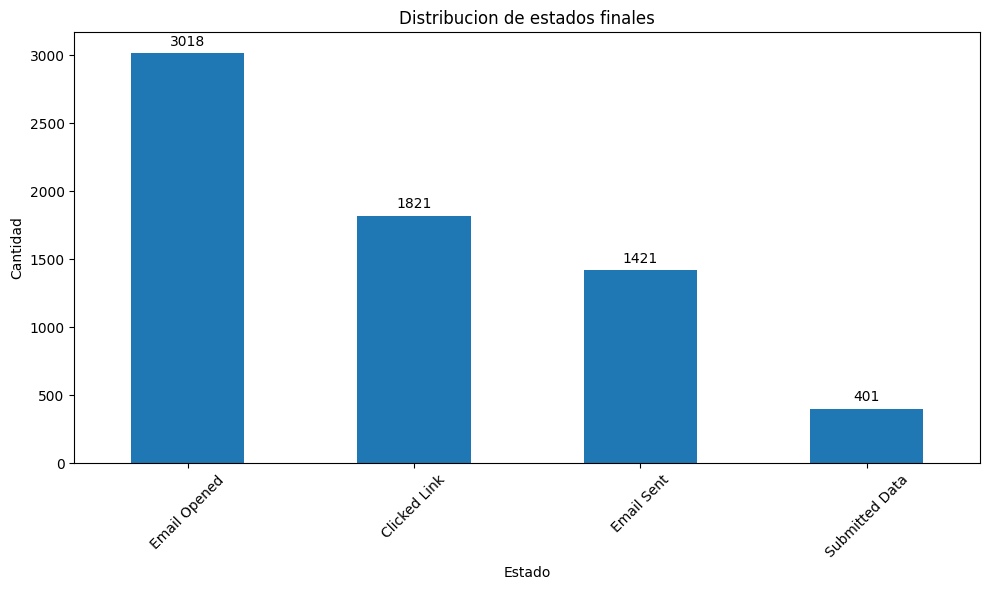

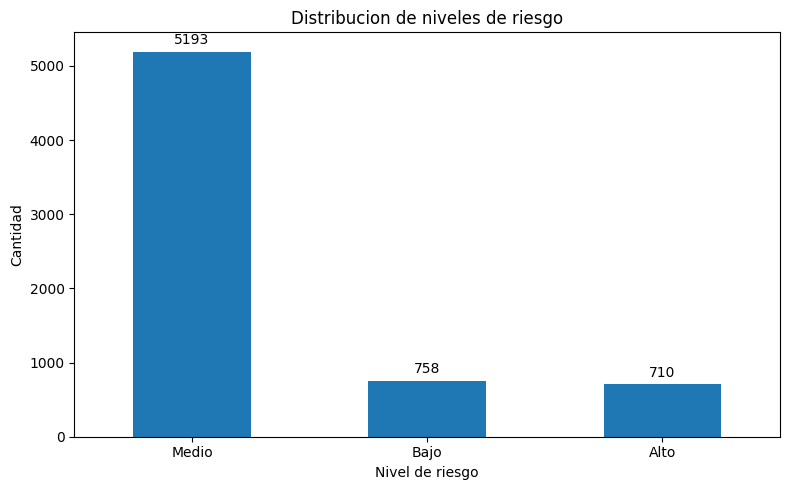

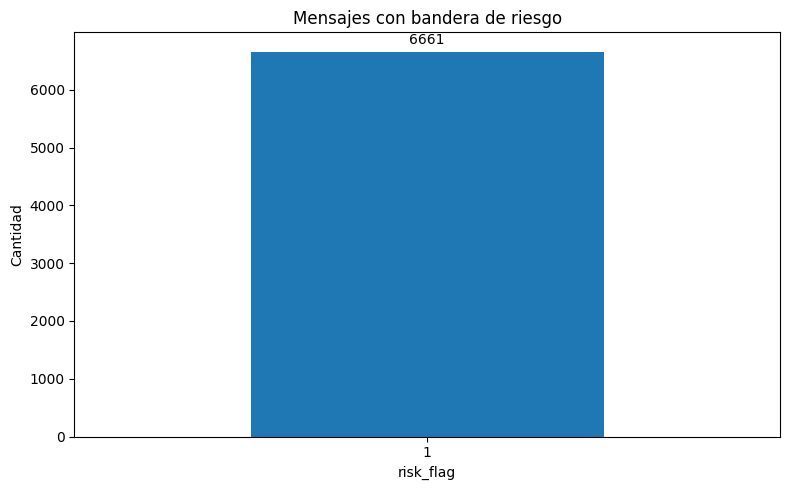

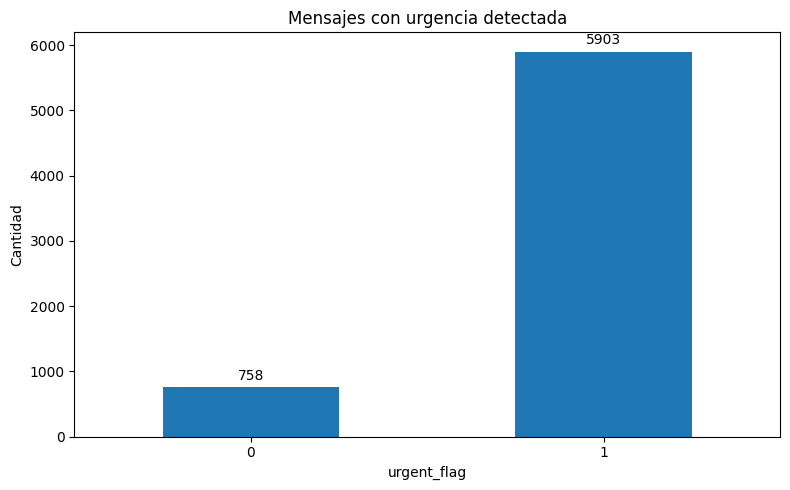

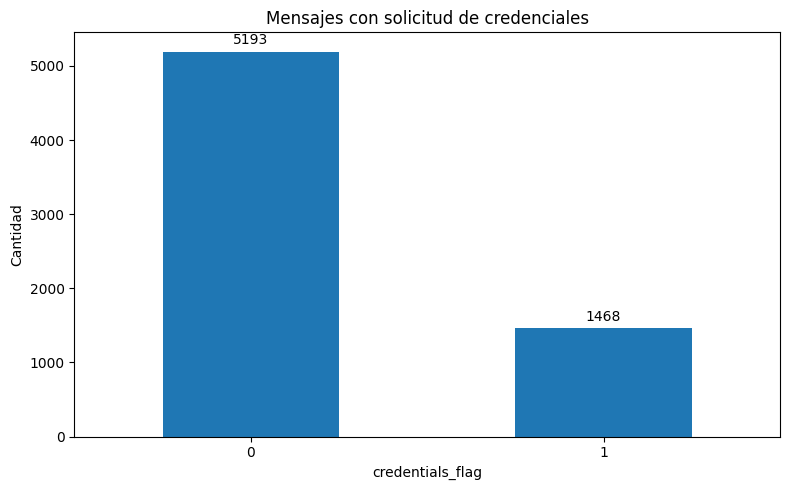

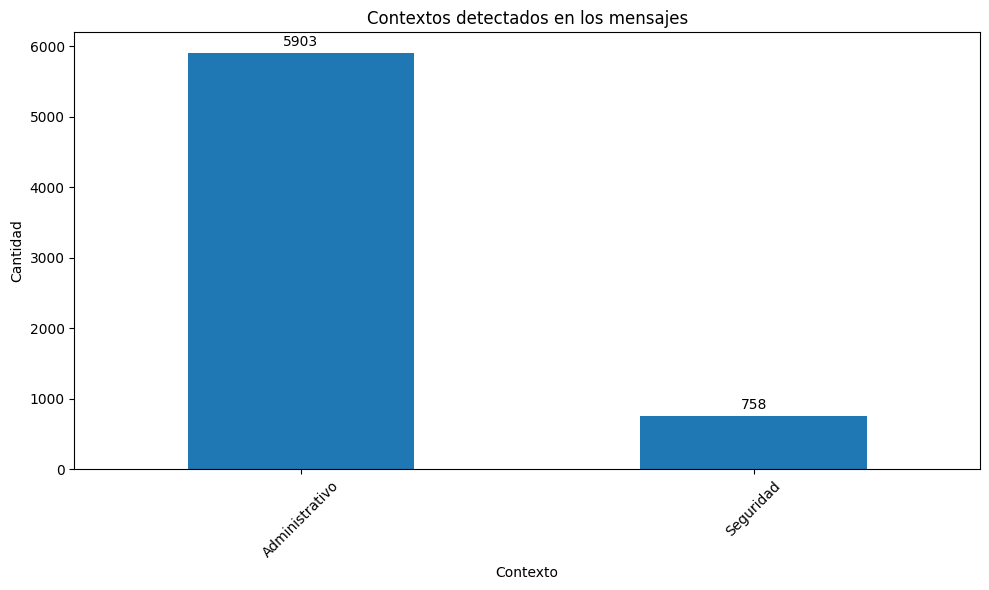


Top campanas:
     campaign_id   campaign_name  total_events
1              2  Campana P1-002            35
40            41  Campana P1-041            35
38            39  Campana P1-039            35
25            26  Campana P1-026            35
62            63  Campana P1-063            35
65            66  Campana P1-066            35
60            61  Campana P1-061            35
232          233  Campana P1-233            35
191          192  Campana P1-192            35
195          196  Campana P1-196            35


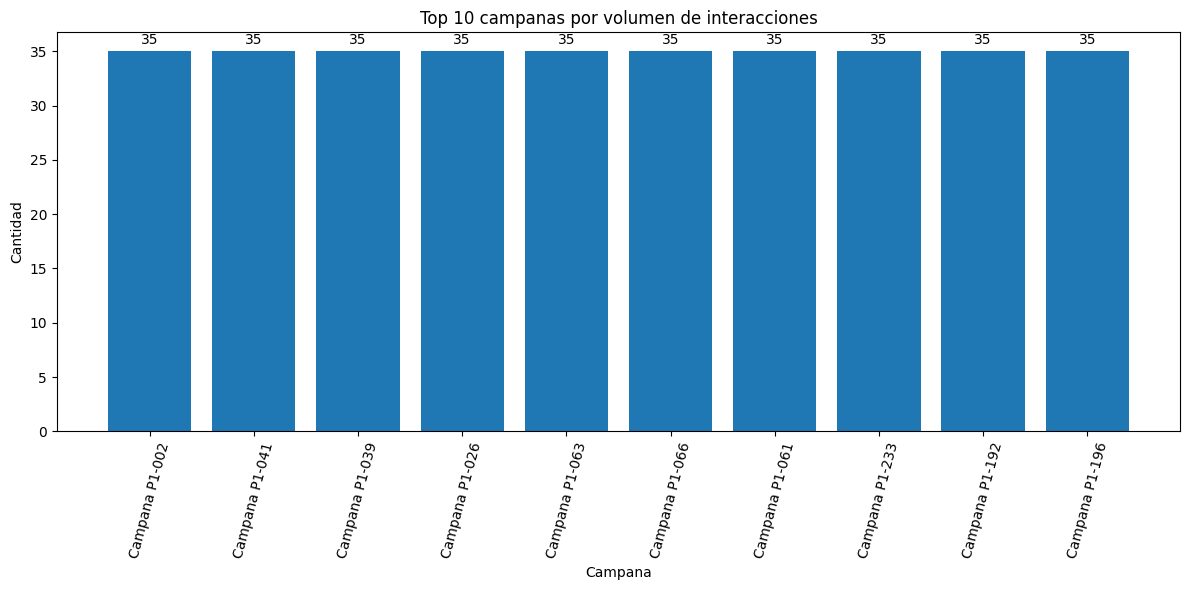


Riesgo por contexto:
risk_level         Alto   Medio   Bajo
context_detected                      
Administrativo    710.0  5193.0    0.0
Seguridad           0.0     0.0  758.0


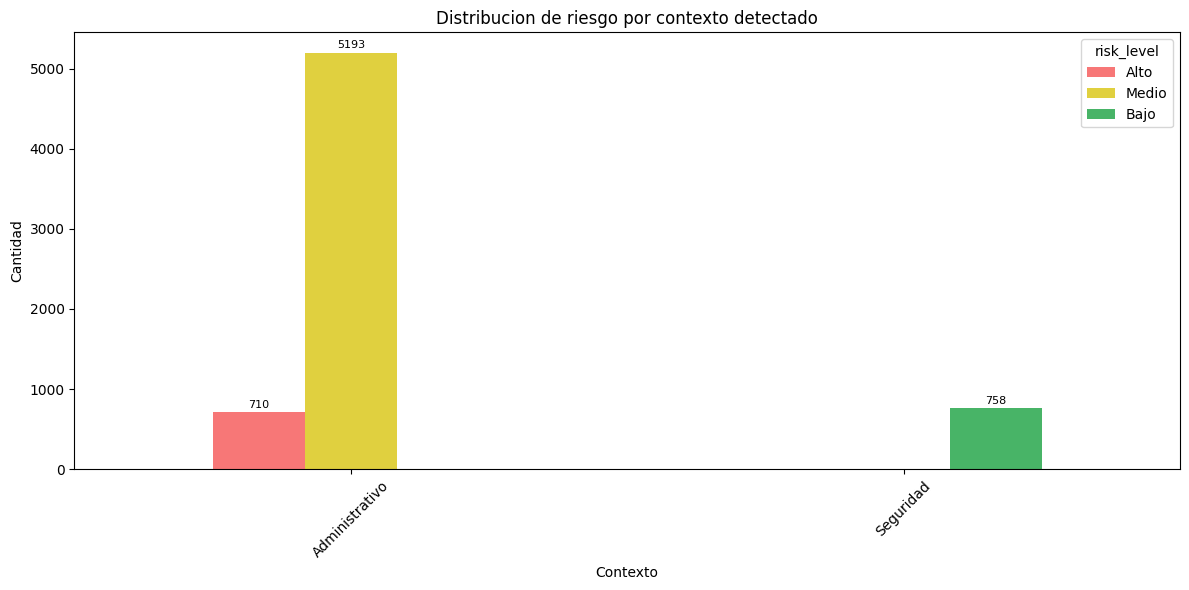

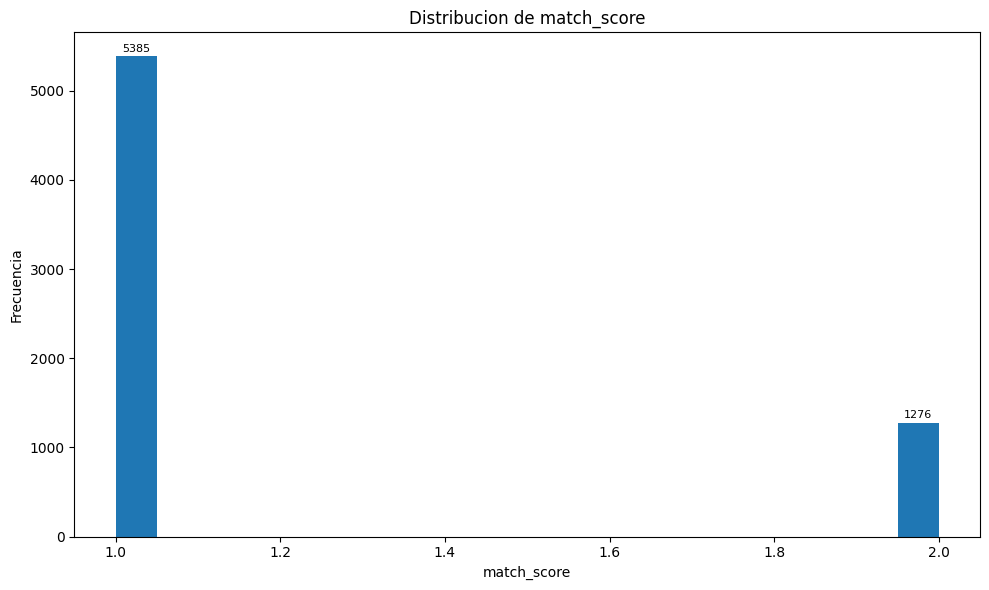


Ejemplos riesgo Bajo:
                                            text_full context_detected  \
88  verificacion de correo empresarial p1 4 verifi...        Seguridad   
89  verificacion de correo empresarial p1 4 verifi...        Seguridad   
90  verificacion de correo empresarial p1 4 verifi...        Seguridad   
91  verificacion de correo empresarial p1 4 verifi...        Seguridad   
92  verificacion de correo empresarial p1 4 verifi...        Seguridad   

   risk_level  match_score  
88       Bajo            1  
89       Bajo            1  
90       Bajo            1  
91       Bajo            1  
92       Bajo            1  

Ejemplos riesgo Medio:
                                           text_full context_detected  \
0  actualizacion de cuenta corporativa p1 1 actua...   Administrativo   
1  actualizacion de cuenta corporativa p1 1 actua...   Administrativo   
2  actualizacion de cuenta corporativa p1 1 actua...   Administrativo   
3  actualizacion de cuenta corporativa p1 

' dashboard_summary.to_sql(\n    "dashboard_summary",\n    con=engine,\n    if_exists="replace",\n    index=False\n)\n\ncampaign_total.to_sql(\n    "dashboard_campaign_total",\n    con=engine,\n    if_exists="replace",\n    index=False\n)\n\ncontext_risk_summary.to_sql(\n    "dashboard_context_risk",\n    con=engine,\n    if_exists="replace",\n    index=False\n)\n\nprint("\nTablas del dashboard guardadas en MySQL") '

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def add_data_labels(ax, fmt="{:.0f}", fontsize=10, padding=3):

    for p in ax.patches:
        width = p.get_width()
        height = p.get_height()

        if height is not None and height > 0:
            x = p.get_x() + width / 2
            y = height
            ax.annotate(
                fmt.format(height),
                (x, y),
                ha="center",
                va="bottom",
                textcoords="offset points",
                xytext=(0, padding),
                fontsize=fontsize
            )

df_dash = df_features.copy()

print("Shape:", df_dash.shape)
print("\nColumnas:")
print(df_dash.columns.tolist())

total_records = len(df_dash)

status_counts = df_dash["result_status"].value_counts(dropna=False)
status_pct = round((status_counts / total_records) * 100, 2)

risk_counts = df_dash["risk_level"].value_counts(dropna=False)
context_counts = df_dash["context_detected"].value_counts(dropna=False)

risk_flag_counts = df_dash["risk_flag"].value_counts(dropna=False)
urgent_flag_counts = df_dash["urgent_flag"].value_counts(dropna=False)
credentials_flag_counts = df_dash["credentials_flag"].value_counts(dropna=False)

dashboard_summary = pd.DataFrame({
    "metric": [
        "total_records",
        "email_opened",
        "clicked_link",
        "email_sent",
        "submitted_data",
        "risk_bajo",
        "risk_medio",
        "risk_alto",
        "risk_none",
        "risk_flag_1",
        "urgent_flag_1",
        "credentials_flag_1"
    ],
    "value": [
        total_records,
        status_counts.get("Email Opened", 0),
        status_counts.get("Clicked Link", 0),
        status_counts.get("Email Sent", 0),
        status_counts.get("Submitted Data", 0),
        risk_counts.get("Bajo", 0),
        risk_counts.get("Medio", 0),
        risk_counts.get("Alto", 0),
        risk_counts.get("None", 0),
        risk_flag_counts.get(1, 0),
        urgent_flag_counts.get(1, 0),
        credentials_flag_counts.get(1, 0)
    ]
})

print("\nResumen dashboard:")
print(dashboard_summary)

plt.figure(figsize=(10, 6))
ax = status_counts.plot(kind="bar")
plt.title("Distribucion de estados finales")
plt.xlabel("Estado")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
add_data_labels(ax)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
ax = risk_counts.plot(kind="bar")
plt.title("Distribucion de niveles de riesgo")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
add_data_labels(ax)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
ax = risk_flag_counts.sort_index().plot(kind="bar")
plt.title("Mensajes con bandera de riesgo")
plt.xlabel("risk_flag")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
add_data_labels(ax)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
ax = urgent_flag_counts.sort_index().plot(kind="bar")
plt.title("Mensajes con urgencia detectada")
plt.xlabel("urgent_flag")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
add_data_labels(ax)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
ax = credentials_flag_counts.sort_index().plot(kind="bar")
plt.title("Mensajes con solicitud de credenciales")
plt.xlabel("credentials_flag")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
add_data_labels(ax)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
ax = context_counts.plot(kind="bar")
plt.title("Contextos detectados en los mensajes")
plt.xlabel("Contexto")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
add_data_labels(ax)
plt.tight_layout()
plt.show()

campaign_total = (
    df_dash.groupby(["campaign_id", "campaign_name"])
    .size()
    .reset_index(name="total_events")
    .sort_values("total_events", ascending=False)
)

print("\nTop campanas:")
print(campaign_total.head(10))

top_campaigns = campaign_total.head(10)

plt.figure(figsize=(12, 6))
ax = plt.gca()
ax.bar(top_campaigns["campaign_name"], top_campaigns["total_events"])
plt.title("Top 10 campanas por volumen de interacciones")
plt.xlabel("Campana")
plt.ylabel("Cantidad")
plt.xticks(rotation=75)
add_data_labels(ax)
plt.tight_layout()
plt.show()

context_risk_summary = (
    df_dash.groupby(["context_detected", "risk_level"])
    .size()
    .reset_index(name="count")
)

context_risk_pivot = context_risk_summary.pivot(
    index="context_detected",
    columns="risk_level",
    values="count"
).fillna(0)

risk_order = ["Alto", "Medio", "Bajo"]
context_risk_pivot = context_risk_pivot[
    [c for c in risk_order if c in context_risk_pivot.columns]
]

print("\nRiesgo por contexto:")
print(context_risk_pivot)

risk_colors = {
    "Alto": "#f77777",
    "Medio": "#e0d03f",
    "Bajo": "#48b467"
}

colors = [risk_colors[col] for col in context_risk_pivot.columns]

ax = context_risk_pivot.plot(
    kind="bar",
    figsize=(12, 6),
    color=colors
)

plt.title("Distribucion de riesgo por contexto detectado")
plt.xlabel("Contexto")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)

add_data_labels(ax, fontsize=8, padding=2)

plt.legend(title="risk_level")
plt.tight_layout()
plt.show()

if "match_score" in df_dash.columns:
    plt.figure(figsize=(10, 6))
    ax = df_dash["match_score"].plot(kind="hist", bins=20)
    plt.title("Distribucion de match_score")
    plt.xlabel("match_score")
    plt.ylabel("Frecuencia")
    add_data_labels(ax, fontsize=8, padding=2)
    plt.tight_layout()
    plt.show()

print("\nEjemplos riesgo Bajo:")
print(
    df_dash.loc[
        df_dash["risk_level"] == "Bajo",
        ["text_full", "context_detected", "risk_level", "match_score"]
    ].head(5)
)

print("\nEjemplos riesgo Medio:")
print(
    df_dash.loc[
        df_dash["risk_level"] == "Medio",
        ["text_full", "context_detected", "risk_level", "match_score"]
    ].head(5)
)

print("\nEjemplos riesgo Alto:")
print(
    df_dash.loc[
        df_dash["risk_level"] == "Alto",
        ["text_full", "context_detected", "risk_level", "match_score"]
    ].head(5)
)

if "predicted_status" in df_dash.columns:
    comparison = pd.crosstab(
        df_dash["result_status"],
        df_dash["predicted_status"],
        rownames=["Real"],
        colnames=["Predicho"]
    )

    print("\nComparacion real vs predicho:")
    print(comparison)

    ax = comparison.plot(kind="bar", figsize=(12, 6))
    plt.title("Comparacion entre estado real y estado predicho")
    plt.xlabel("Estado real")
    plt.ylabel("Cantidad")
    plt.xticks(rotation=45)
    add_data_labels(ax, fontsize=8, padding=2)
    plt.tight_layout()
    plt.show()

""" dashboard_summary.to_sql(
    "dashboard_summary",
    con=engine,
    if_exists="replace",
    index=False
)

campaign_total.to_sql(
    "dashboard_campaign_total",
    con=engine,
    if_exists="replace",
    index=False
)

context_risk_summary.to_sql(
    "dashboard_context_risk",
    con=engine,
    if_exists="replace",
    index=False
)

print("\nTablas del dashboard guardadas en MySQL") """

Riesgo detectado

Preparar dataset final

In [ ]:
import pandas as pd
import numpy as np

df_model = df_features.copy()

feature_cols = [
    "text_full",
    "risk_flag",
    "urgent_flag",
    "credentials_flag",
    "context_detected",
    "risk_level"
]

target_col = "result_status"

df_model = df_model[feature_cols + [target_col]].copy()

df_model["text_full"] = df_model["text_full"].fillna("")
df_model["context_detected"] = df_model["context_detected"].fillna("None")
df_model["risk_level"] = df_model["risk_level"].fillna("None")

for col in ["risk_flag", "urgent_flag", "credentials_flag"]:
    df_model[col] = df_model[col].fillna(0).astype(int)

df_model = df_model.dropna(subset=[target_col]).copy()

print(df_model.shape)
print(df_model[target_col].value_counts(dropna=False))
df_model.head()

(6661, 7)
result_status
Email Opened      3018
Clicked Link      1821
Email Sent        1421
Submitted Data     401
Name: count, dtype: int64


,text_full,risk_flag,urgent_flag,credentials_flag,context_detected,risk_level,result_status
0,actualizacion de cuenta corporativa p1 1 actua...,1,1,0,Administrativo,Medio,Email Opened
1,actualizacion de cuenta corporativa p1 1 actua...,1,1,0,Administrativo,Medio,Email Opened
2,actualizacion de cuenta corporativa p1 1 actua...,1,1,0,Administrativo,Medio,Email Opened
3,actualizacion de cuenta corporativa p1 1 actua...,1,1,0,Administrativo,Medio,Email Opened
4,actualizacion de cuenta corporativa p1 1 actua...,1,1,0,Administrativo,Medio,Email Opened


Separar X e y

In [32]:
X = df_model[feature_cols].copy()
y = df_model[target_col].copy()

Train / test split

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Preprocesamiento mixto

Aquí sí vamos a usar:

* texto → TfidfVectorizer
* categóricas → OneHotEncoder
* numéricas → passthrough

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder

text_col = "text_full"
cat_cols = ["context_detected", "risk_level"]
num_cols = ["risk_flag", "urgent_flag", "credentials_flag"]

preprocessor = ColumnTransformer([
    ("text", TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95), text_col),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols)
])

Modelo final

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contai

Evaluación


In [36]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.18979744936234058

Classification report:
                precision    recall  f1-score   support

  Clicked Link       0.29      0.20      0.23       365
  Email Opened       0.38      0.15      0.22       604
    Email Sent       0.19      0.24      0.21       284
Submitted Data       0.04      0.26      0.08        80

      accuracy                           0.19      1333
     macro avg       0.23      0.21      0.18      1333
  weighted avg       0.29      0.19      0.21      1333



Matriz de confusión:

In [37]:
cm = pd.DataFrame(
    confusion_matrix(y_test, y_pred, labels=sorted(y.unique())),
    index=sorted(y.unique()),
    columns=sorted(y.unique())
)

print(cm)

                Clicked Link  Email Opened  Email Sent  Submitted Data
Clicked Link              72            70          93             130
Email Opened             111            91         176             226
Email Sent                55            58          69             102
Submitted Data            14            20          25              21


Guardar modelo final

In [38]:
import joblib

joblib.dump(model, "modelo_ml_final.joblib")
print("Modelo guardado en modelo_ml_final.joblib")

Modelo guardado en modelo_ml_final.joblib


Guardar registro del modelo en MySQL

In [39]:
""" from datetime import datetime
import pandas as pd

model_registry = pd.DataFrame([{
    "model_name": "modelo_ml_final",
    "version": "v1",
    "trained_at": datetime.now(),
    "target": "result_status",
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "file_path": "modelo_ml_final.joblib",
    "n_rows_train": int(len(X_train)),
    "n_rows_test": int(len(X_test))
}])

model_registry.to_sql(
    "ml_models_registry",
    con=engine,
    if_exists="append",
    index=False
)

print("Registro del modelo guardado en ml_models_registry") """

' from datetime import datetime\nimport pandas as pd\n\nmodel_registry = pd.DataFrame([{\n    "model_name": "modelo_ml_final",\n    "version": "v1",\n    "trained_at": datetime.now(),\n    "target": "result_status",\n    "accuracy": float(accuracy_score(y_test, y_pred)),\n    "file_path": "modelo_ml_final.joblib",\n    "n_rows_train": int(len(X_train)),\n    "n_rows_test": int(len(X_test))\n}])\n\nmodel_registry.to_sql(\n    "ml_models_registry",\n    con=engine,\n    if_exists="append",\n    index=False\n)\n\nprint("Registro del modelo guardado en ml_models_registry") '

In [40]:
X_pred = df_features[[
    "text_full",
    "risk_flag",
    "urgent_flag",
    "credentials_flag",
    "context_detected",
    "risk_level"
]].copy()

df_features["predicted_status"] = model.predict(X_pred)

if hasattr(model, "predict_proba"):
    probs = model.predict_proba(X_pred)
    df_features["predicted_confidence"] = probs.max(axis=1)

Distribucion de predicciones

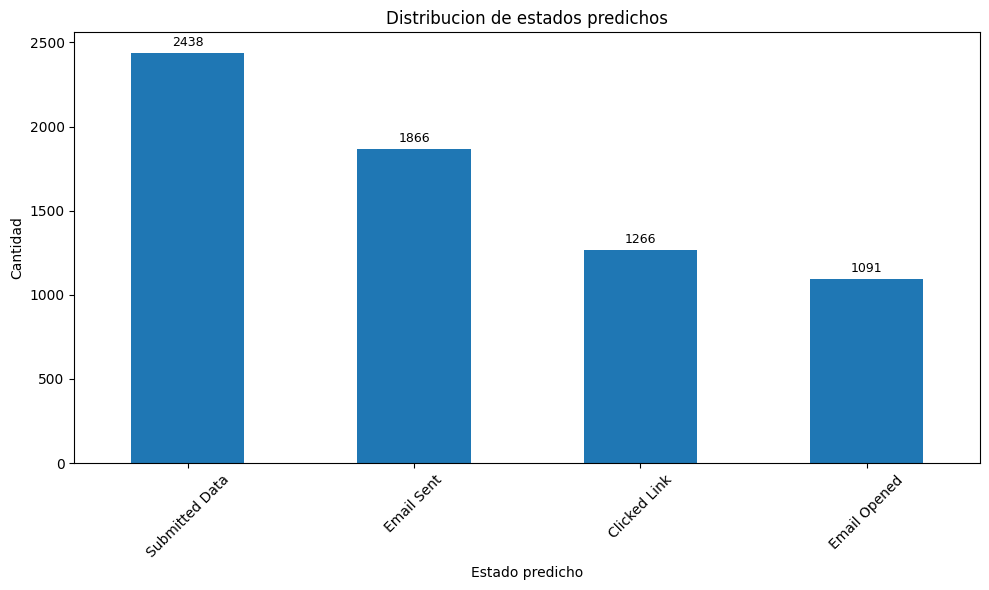

In [41]:
import matplotlib.pyplot as plt

pred_counts = df_features["predicted_status"].value_counts()

plt.figure(figsize=(10,6))
ax = pred_counts.plot(kind="bar")
plt.title("Distribucion de estados predichos")
plt.xlabel("Estado predicho")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{int(height)}",
        (p.get_x() + p.get_width()/2, height),
        ha="center",
        va="bottom",
        textcoords="offset points",
        xytext=(0, 3),
        fontsize=9
    )

plt.tight_layout()
plt.show()

Comparacion real vs predicho

risk_level       Bajo  Medio   Alto
result_status                      
Email Sent      11.40  77.62  10.98
Clicked Link    11.92  78.14   9.94
Email Opened    11.30  77.97  10.74
Submitted Data   9.48  78.30  12.22


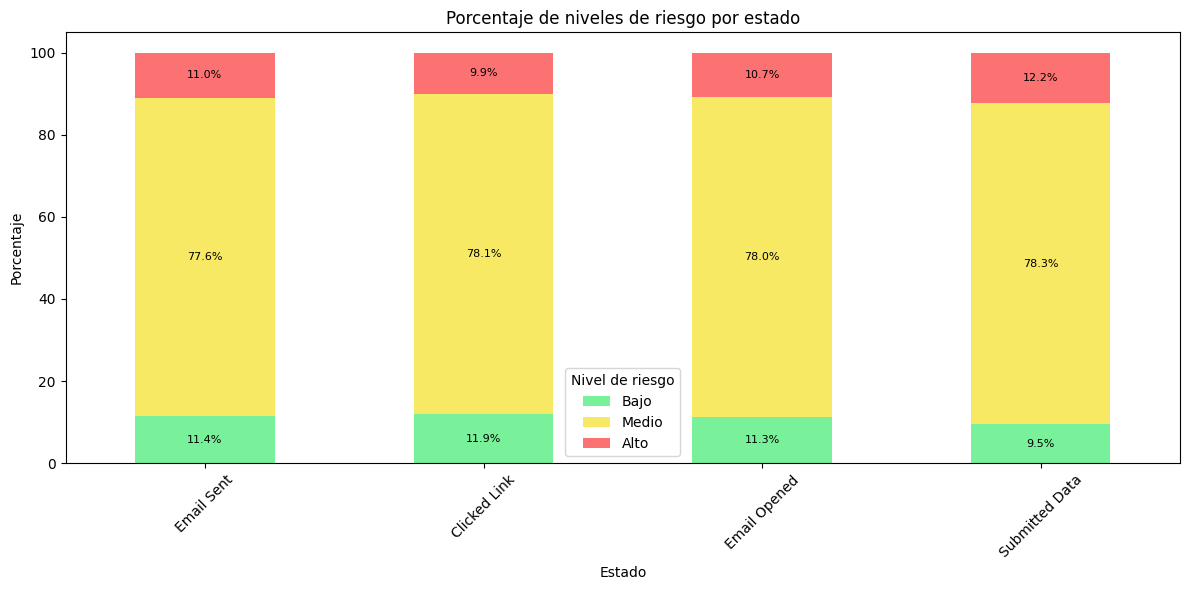

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

risk_by_status = pd.crosstab(
    df_features["result_status"],
    df_features["risk_level"]
)

status_order = ["Email Sent", "Clicked Link", "Email Opened", "Submitted Data"]
risk_by_status = risk_by_status.reindex(
    [s for s in status_order if s in risk_by_status.index]
)

risk_order = ["Bajo", "Medio", "Alto"]
risk_by_status = risk_by_status[
    [c for c in risk_order if c in risk_by_status.columns]
]

risk_by_status_pct = risk_by_status.div(risk_by_status.sum(axis=1), axis=0) * 100

print(risk_by_status_pct.round(2))

risk_colors = {
    "Bajo": "#79f19b",
    "Medio": "#f8e965",
    "Alto": "#fc7272"
}

colors = [risk_colors[col] for col in risk_by_status_pct.columns]

ax = risk_by_status_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=colors
)

plt.title("Porcentaje de niveles de riesgo por estado")
plt.xlabel("Estado")
plt.ylabel("Porcentaje")
plt.xticks(rotation=45)
plt.legend(title="Nivel de riesgo")

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{height:.1f}%",
            (p.get_x() + p.get_width() / 2, p.get_y() + height / 2),
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.show()

Predicciones por nivel de riesgo


Estados actuales por nivel de riesgo:
result_status  Clicked Link  Email Opened  Email Sent  Submitted Data
risk_level                                                           
Alto                    181           324         156              49
Bajo                    217           341         162              38
Medio                  1423          2353        1103             314


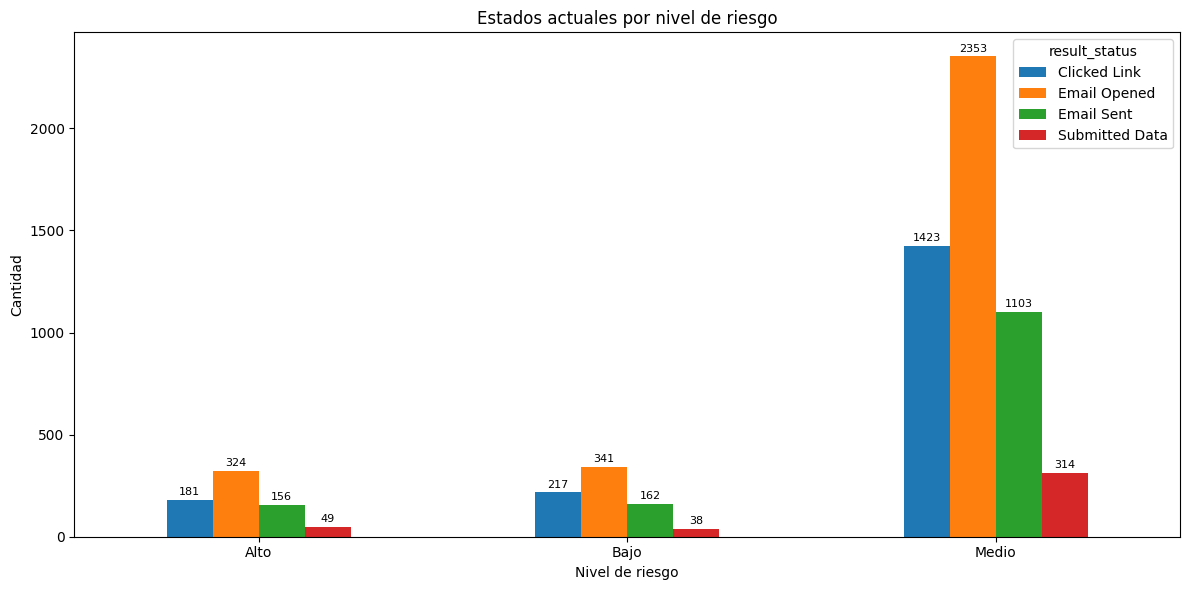

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

current_status_summary = (
    df_dash.groupby(["risk_level", "result_status"])
    .size()
    .reset_index(name="count")
)

current_status_pivot = current_status_summary.pivot(
    index="risk_level",
    columns="result_status",
    values="count"
).fillna(0)

print("\nEstados actuales por nivel de riesgo:")
print(current_status_pivot)

def add_data_labels(ax, fontsize=8, padding=2):
    for container in ax.containers:
        ax.bar_label(container, fontsize=fontsize, padding=padding)

ax = current_status_pivot.plot(kind="bar", figsize=(12, 6))

plt.title("Estados actuales por nivel de riesgo")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.legend(title="result_status")
add_data_labels(ax, fontsize=8, padding=2)
plt.tight_layout()
plt.show()

predicted_status  Clicked Link  Email Opened  Email Sent  Submitted Data
risk_level                                                              
Alto                         0             0         333             377
Bajo                       189           159         410               0
Medio                     1077           932        1123            2061


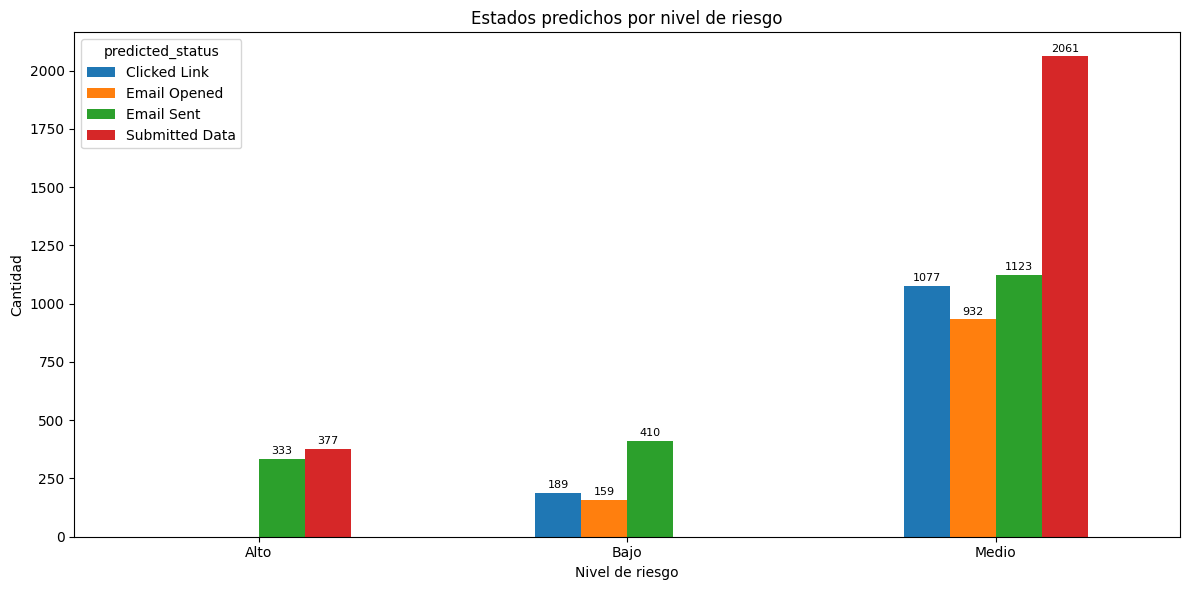

In [44]:
pred_risk = pd.crosstab(
    df_features["risk_level"],
    df_features["predicted_status"]
)

print(pred_risk)

ax = pred_risk.plot(kind="bar", figsize=(12,6))
plt.title("Estados predichos por nivel de riesgo")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width()/2, height),
            ha="center",
            va="bottom",
            textcoords="offset points",
            xytext=(0, 2),
            fontsize=8
        )

plt.tight_layout()
plt.show()

Predicciones por contexto detectado

predicted_status  Clicked Link  Email Opened  Email Sent  Submitted Data
context_detected                                                        
Administrativo            1077           932        1456            2438
Seguridad                  189           159         410               0


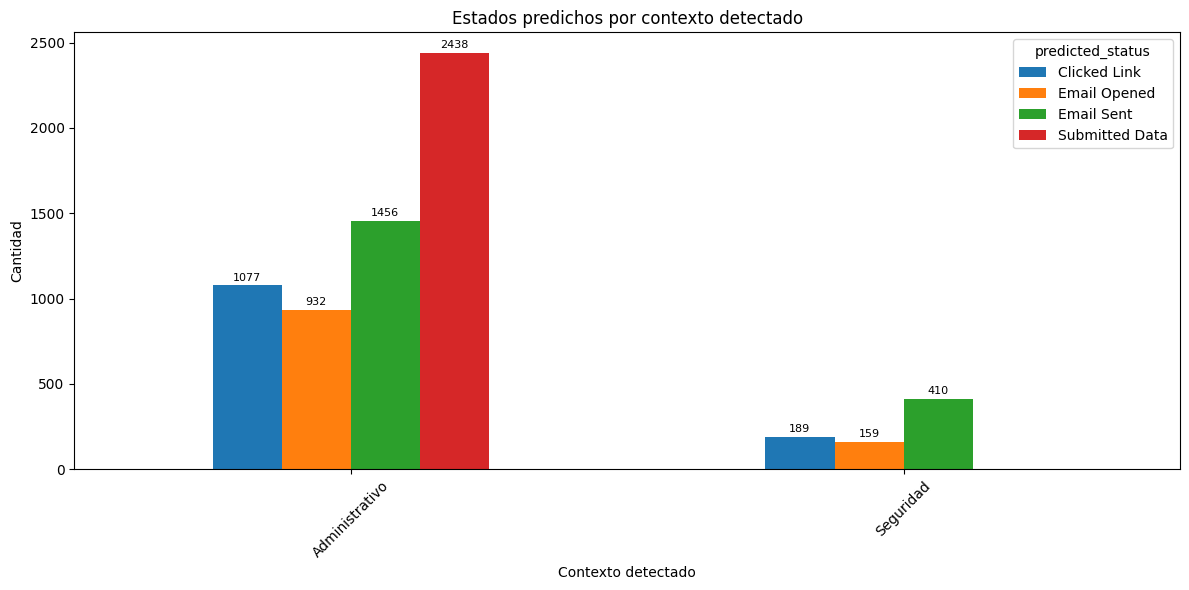

In [45]:
pred_context = pd.crosstab(
    df_features["context_detected"],
    df_features["predicted_status"]
)

print(pred_context)

ax = pred_context.plot(kind="bar", figsize=(12,6))
plt.title("Estados predichos por contexto detectado")
plt.xlabel("Contexto detectado")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width()/2, height),
            ha="center",
            va="bottom",
            textcoords="offset points",
            xytext=(0, 2),
            fontsize=8
        )

plt.tight_layout()
plt.show()

Confianza de prediccion

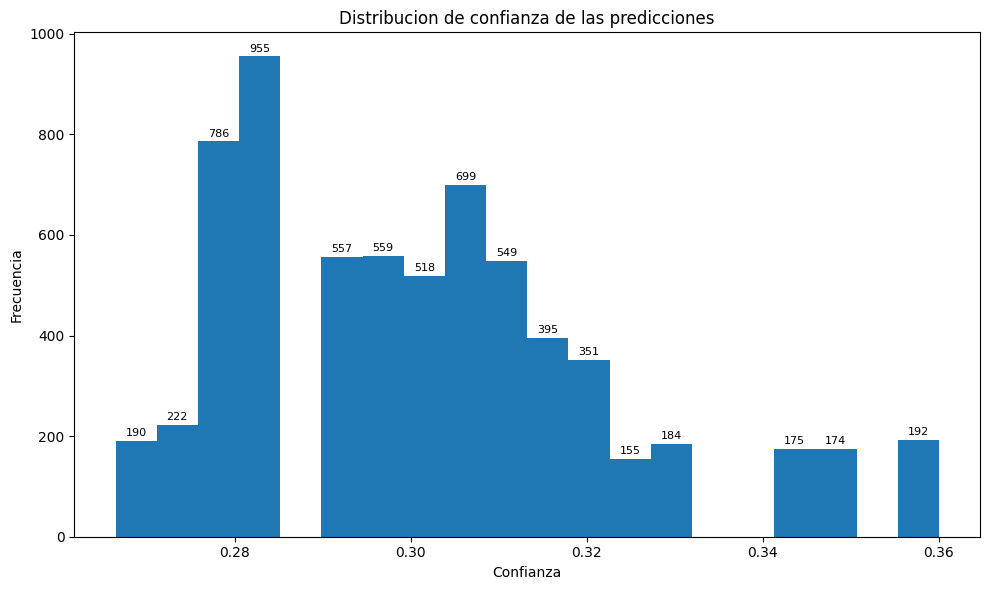

In [46]:
if "predicted_confidence" in df_features.columns:
    plt.figure(figsize=(10,6))
    ax = df_features["predicted_confidence"].plot(kind="hist", bins=20)
    plt.title("Distribucion de confianza de las predicciones")
    plt.xlabel("Confianza")
    plt.ylabel("Frecuencia")

    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(
                f"{int(height)}",
                (p.get_x() + p.get_width()/2, height),
                ha="center",
                va="bottom",
                textcoords="offset points",
                xytext=(0, 2),
                fontsize=8
            )

    plt.tight_layout()
    plt.show()

Top campañas segun prediccion

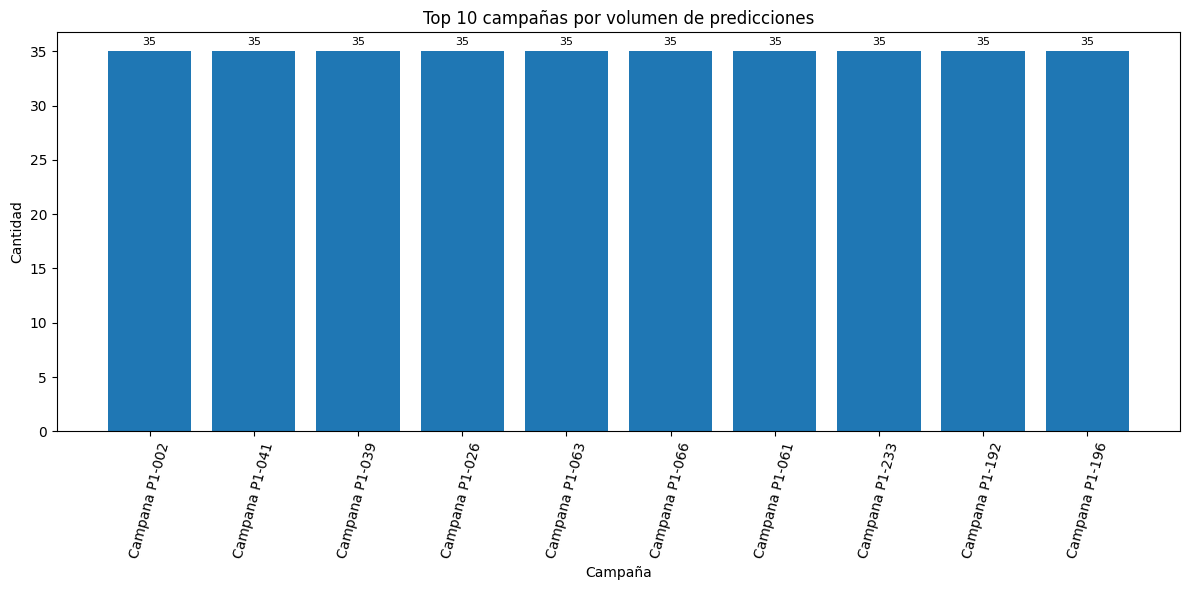

In [47]:
campaign_pred = (
    df_features.groupby(["campaign_name", "predicted_status"])
    .size()
    .reset_index(name="count")
)

campaign_pred_total = (
    campaign_pred.groupby("campaign_name")["count"]
    .sum()
    .reset_index(name="total_predicted")
    .sort_values("total_predicted", ascending=False)
)

top_campaigns_pred = campaign_pred_total.head(10)

plt.figure(figsize=(12,6))
ax = plt.gca()
ax.bar(top_campaigns_pred["campaign_name"], top_campaigns_pred["total_predicted"])
plt.title("Top 10 campañas por volumen de predicciones")
plt.xlabel("Campaña")
plt.ylabel("Cantidad")
plt.xticks(rotation=75)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{int(height)}",
        (p.get_x() + p.get_width()/2, height),
        ha="center",
        va="bottom",
        textcoords="offset points",
        xytext=(0, 3),
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [48]:
predictions_table = df_features[[
    "campaign_id",
    "campaign_name",
    "user_id",
    "r_id",
    "result_status",
    "predicted_status",
    "risk_level",
    "context_detected"
]].copy()

if "predicted_confidence" in predictions_table.columns:
    predictions_table["predicted_confidence"] = df_features["predicted_confidence"]

predictions_table.to_sql(
    "dashboard_predictions",
    con=engine,
    if_exists="replace",
    index=False
)

6661


Estados actuales por nivel de riesgo (%):
result_status  Clicked Link  Email Opened  Email Sent  Submitted Data
risk_level                                                           
Alto                  25.49         45.63       21.97            6.90
Bajo                  28.63         44.99       21.37            5.01
Medio                 27.40         45.31       21.24            6.05


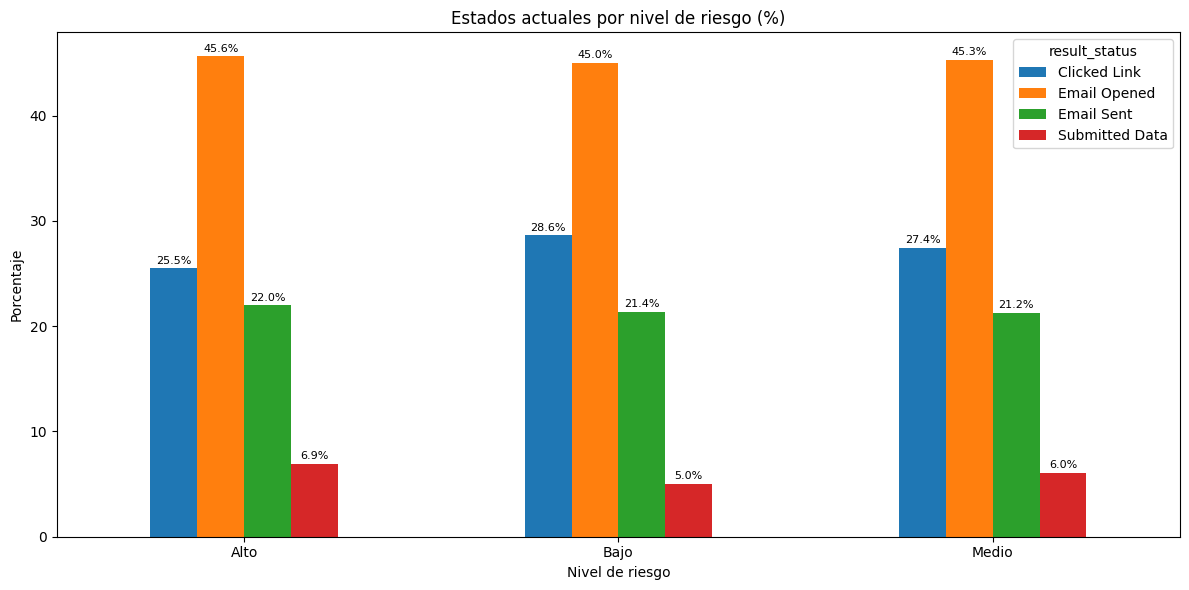

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

current_status_summary = (
    df_dash.groupby(["risk_level", "result_status"])
    .size()
    .reset_index(name="count")
)

current_status_pivot = current_status_summary.pivot(
    index="risk_level",
    columns="result_status",
    values="count"
).fillna(0)


current_status_pct = current_status_pivot.div(
    current_status_pivot.sum(axis=1), axis=0
) * 100

print("\nEstados actuales por nivel de riesgo (%):")
print(current_status_pct.round(2))

def add_data_labels_pct(ax, fontsize=8, padding=2):
    for container in ax.containers:
        labels = [f"{v:.1f}%" if v > 0 else "" for v in container.datavalues]
        ax.bar_label(container, labels=labels, fontsize=fontsize, padding=padding)

ax = current_status_pct.plot(kind="bar", figsize=(12, 6))

plt.title("Estados actuales por nivel de riesgo (%)")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.legend(title="result_status")
add_data_labels_pct(ax, fontsize=8, padding=2)
plt.tight_layout()
plt.show()

predicted_status  Clicked Link  Email Opened  Email Sent  Submitted Data
risk_level                                                              
Alto                         0             0         333             377
Bajo                       189           159         410               0
Medio                     1077           932        1123            2061


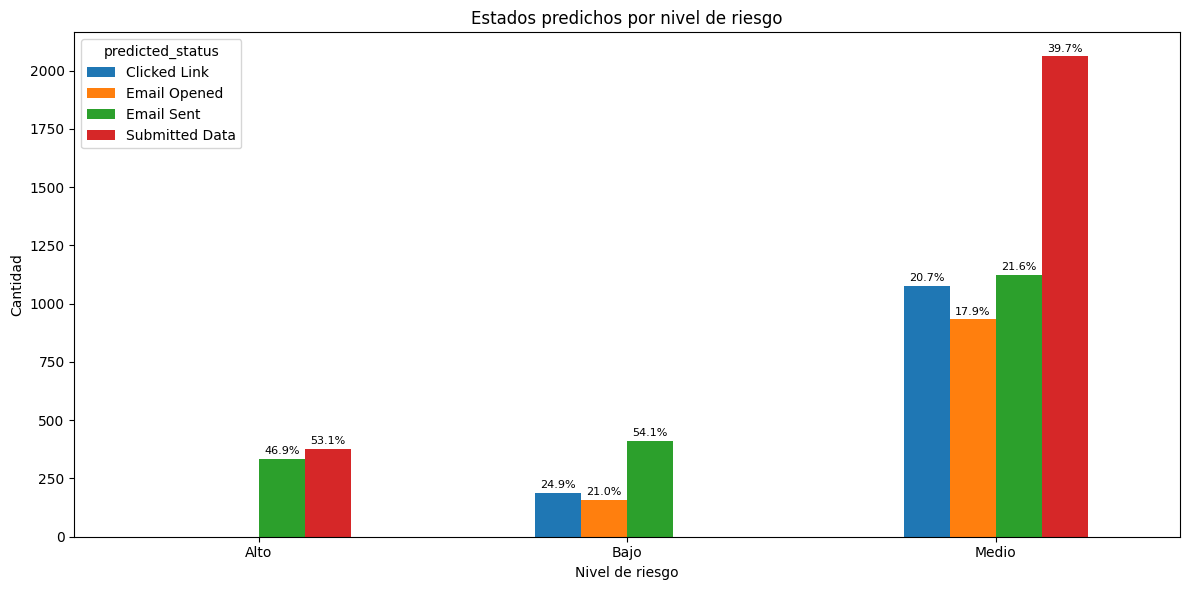

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

pred_risk = pd.crosstab(
    df_features["risk_level"],
    df_features["predicted_status"]
)

print(pred_risk)

pred_risk_pct = pred_risk.div(pred_risk.sum(axis=1), axis=0) * 100

ax = pred_risk.plot(kind="bar", figsize=(12, 6))
plt.title("Estados predichos por nivel de riesgo")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)

for container_idx, container in enumerate(ax.containers):
    col_name = pred_risk.columns[container_idx]

    for bar_idx, p in enumerate(container):
        height = p.get_height()

        if height > 0:
            risk_level = pred_risk.index[bar_idx]
            pct = pred_risk_pct.loc[risk_level, col_name]

            ax.annotate(
                f"{pct:.1f}%",
                (p.get_x() + p.get_width() / 2, height),
                ha="center",
                va="bottom",
                textcoords="offset points",
                xytext=(0, 2),
                fontsize=8
            )

plt.tight_layout()
plt.show()

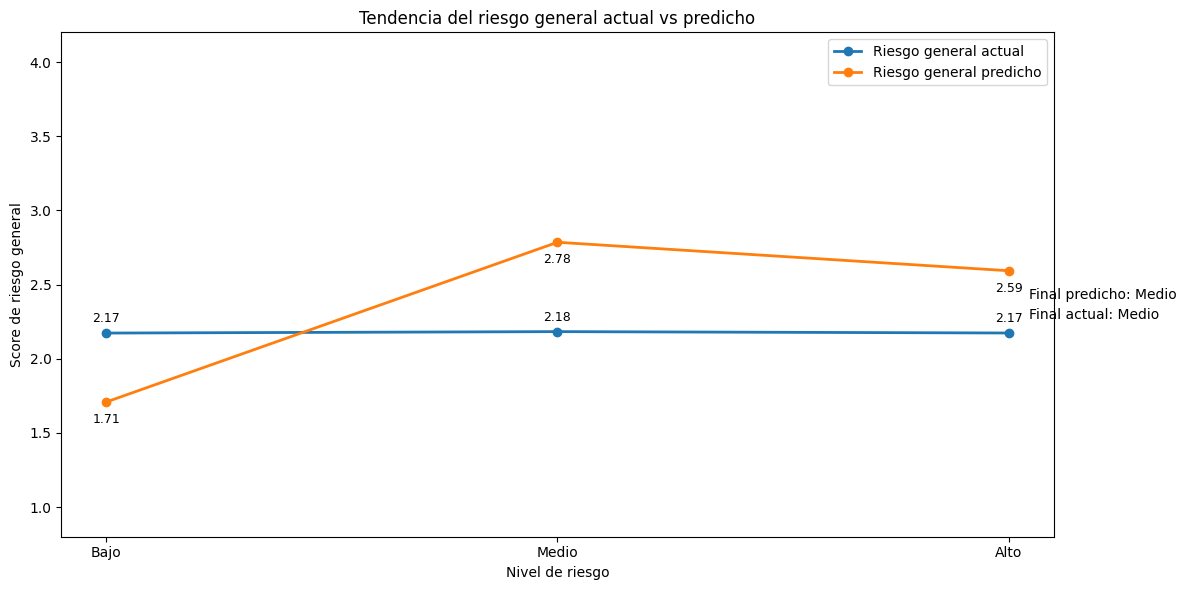

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

risk_order = ["Bajo", "Medio", "Alto"]

status_score = {
    "Email Sent": 1,
    "Email Opened": 2,
    "Clicked Link": 3,
    "Submitted Data": 4
}

current_pct = pd.crosstab(
    df_dash["risk_level"],
    df_dash["result_status"],
    normalize="index"
) * 100

pred_pct = pd.crosstab(
    df_features["risk_level"],
    df_features["predicted_status"],
    normalize="index"
) * 100

current_pct = current_pct.reindex(risk_order).fillna(0)
pred_pct = pred_pct.reindex(risk_order).fillna(0)

all_statuses = [s for s in status_score.keys() if s in current_pct.columns or s in pred_pct.columns]
current_pct = current_pct.reindex(columns=all_statuses).fillna(0)
pred_pct = pred_pct.reindex(columns=all_statuses).fillna(0)

def generalized_risk_score(pct_df, score_map):
    scores = []
    for _, row in pct_df.iterrows():
        total = 0
        for status, score in score_map.items():
            if status in row.index:
                total += row[status] * score
        scores.append(total / 100.0)
    return pd.Series(scores, index=pct_df.index)

current_risk_score = generalized_risk_score(current_pct, status_score)
pred_risk_score = generalized_risk_score(pred_pct, status_score)

def classify_final_risk(score):
    if score < 2.0:
        return "Bajo"
    elif score < 3.0:
        return "Medio"
    else:
        return "Alto"

current_final_class = classify_final_risk(current_risk_score.iloc[-1])
pred_final_class = classify_final_risk(pred_risk_score.iloc[-1])

x = np.arange(len(risk_order))

plt.figure(figsize=(12, 6))

plt.plot(x, current_risk_score.values, marker="o", linewidth=2, label="Riesgo general actual")
plt.plot(x, pred_risk_score.values, marker="o", linewidth=2, label="Riesgo general predicho")

for i, y in enumerate(current_risk_score.values):
    plt.annotate(
        f"{y:.2f}",
        (x[i], y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9
    )

for i, y in enumerate(pred_risk_score.values):
    plt.annotate(
        f"{y:.2f}",
        (x[i], y),
        textcoords="offset points",
        xytext=(0, -15),
        ha="center",
        fontsize=9
    )

plt.annotate(
    f"Final actual: {current_final_class}",
    (x[-1], current_risk_score.iloc[-1]),
    textcoords="offset points",
    xytext=(15, 10),
    ha="left",
    fontsize=10
)

plt.annotate(
    f"Final predicho: {pred_final_class}",
    (x[-1], pred_risk_score.iloc[-1]),
    textcoords="offset points",
    xytext=(15, -20),
    ha="left",
    fontsize=10
)

plt.title("Tendencia del riesgo general actual vs predicho")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Score de riesgo general")
plt.xticks(x, risk_order)
plt.ylim(0.8, 4.2)
plt.legend()
plt.tight_layout()
plt.show()

df_risk_report = pd.DataFrame({
    "risk_level": risk_order,
    "current_risk_score": current_risk_score.values,
    "predicted_risk_score": pred_risk_score.values
})

Columnas de df_matches:
['template_id', 'template_name', 'matched_text', 'context', 'subcontext', 'risk']

Primeras filas de df_matches:
   template_id  template_name             matched_text    context  subcontext  \
0            1  Template P1-1  registro de asignaturas  Academico  Estudiante   
1            1  Template P1-1    portal del estudiante  Academico  Estudiante   
2            1  Template P1-1        horario de clases  Academico  Estudiante   
3            1  Template P1-1   constancia de estudios  Academico  Estudiante   
4            1  Template P1-1        pago de matricula  Academico  Estudiante   

   risk  
0  Bajo  
1  Bajo  
2  Bajo  
3  Bajo  
4  Bajo  

Columnas finales de df_matches:
['template_id', 'template_name', 'matched_text', 'context', 'subcontext', 'risk', 'predicted_risk']
   template_id             matched_text  risk predicted_risk
0            1  registro de asignaturas  Bajo          Medio
1            1    portal del estudiante  Bajo          Medio


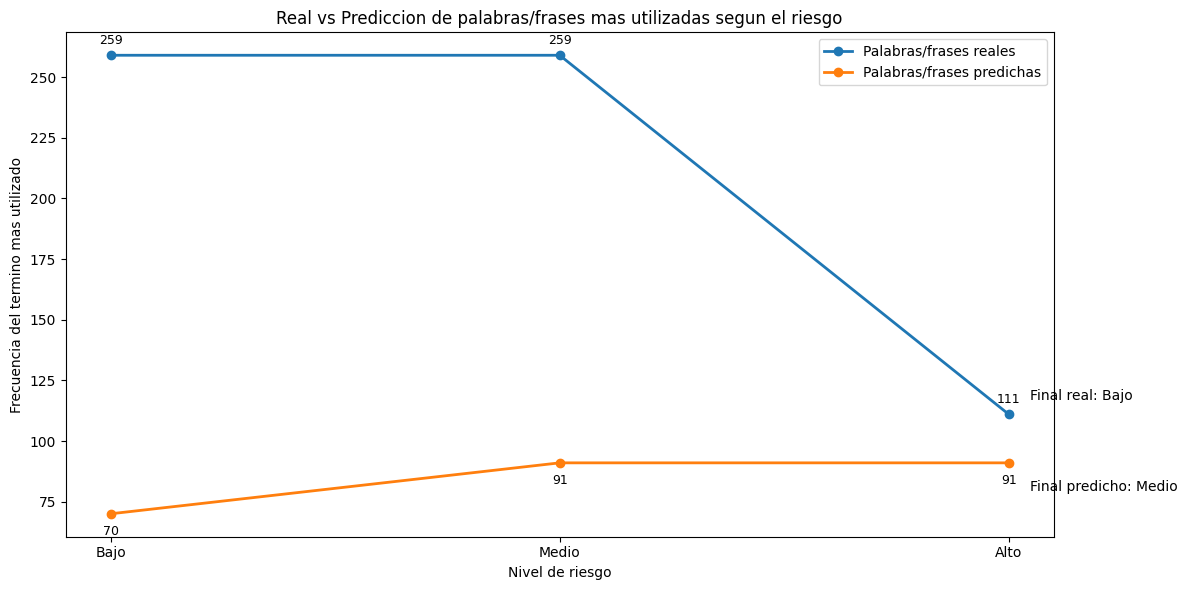

In [ ]:
import re
import unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def normalize_text(s):
    if pd.isna(s):
        return ""
    s = str(s).lower().strip()
    s = ''.join(
        c for c in unicodedata.normalize('NFKD', s)
        if not unicodedata.combining(c)
    )
    s = re.sub(r'[\r\n\t]+', ' ', s)
    s = re.sub(r'\s+', ' ', s)
    return s

df_templates["text_norm"] = df_templates["text"].apply(normalize_text)
df_cls["pattern_norm"] = df_cls["text"].apply(normalize_text)

matches = []

for _, tpl in df_templates.iterrows():
    tpl_words = set(tpl["text_norm"].split())

    for _, cls in df_cls.iterrows():
        cls_words = set(cls["pattern_norm"].split())
        overlap = tpl_words.intersection(cls_words)

        # al menos una coincidencia
        if len(overlap) >= 1:
            matches.append({
                "template_id": tpl["id"],
                "template_name": tpl["name"],
                "matched_text": cls["text"],
                "context": cls["context"],
                "subcontext": cls["subcontext"],
                "risk": cls["risk"]
            })

df_matches = pd.DataFrame(matches)

print("Columnas de df_matches:")
print(df_matches.columns.tolist())
print("\nPrimeras filas de df_matches:")
print(df_matches.head())

status_to_risk = {
    "Email Sent": "Bajo",
    "Email Opened": "Medio",
    "Clicked Link": "Medio",
    "Submitted Data": "Alto"
}


df_template_pred = (
    df_features.copy()
)

df_template_pred["predicted_risk"] = df_template_pred["predicted_status"].map(status_to_risk)


df_template_pred = (
    df_template_pred.groupby("template_id")["predicted_risk"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
    .reset_index()
)


df_matches = df_matches.merge(
    df_template_pred,
    on="template_id",
    how="left"
)

print("\nColumnas finales de df_matches:")
print(df_matches.columns.tolist())
print(df_matches[["template_id", "matched_text", "risk", "predicted_risk"]].head())

risk_order = ["Bajo", "Medio", "Alto"]

def top_term_by_risk(df, risk_col, term_col):
    rows = []

    for risk in risk_order:
        subset = df[df[risk_col] == risk]

        if subset.empty:
            rows.append({
                "risk_level": risk,
                "top_term": "Sin datos",
                "freq": 0
            })
        else:
            vc = subset[term_col].value_counts()
            rows.append({
                "risk_level": risk,
                "top_term": vc.index[0],
                "freq": vc.iloc[0]
            })

    return pd.DataFrame(rows)

real_terms = top_term_by_risk(df_matches, "risk", "matched_text")
pred_terms = top_term_by_risk(df_matches, "predicted_risk", "matched_text")

real_terms = real_terms.set_index("risk_level").reindex(risk_order)
pred_terms = pred_terms.set_index("risk_level").reindex(risk_order)

real_final = real_terms["freq"].idxmax()
pred_final = pred_terms["freq"].idxmax()

x = np.arange(len(risk_order))

plt.figure(figsize=(12, 6))

plt.plot(x, real_terms["freq"].values, marker="o", linewidth=2, label="Palabras/frases reales")
plt.plot(x, pred_terms["freq"].values, marker="o", linewidth=2, label="Palabras/frases predichas")


for i, y in enumerate(real_terms["freq"].values):
    plt.annotate(
        f"{int(y)}",
        (x[i], y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9
    )

for i, y in enumerate(pred_terms["freq"].values):
    plt.annotate(
        f"{int(y)}",
        (x[i], y),
        textcoords="offset points",
        xytext=(0, -15),
        ha="center",
        fontsize=9
    )


plt.annotate(
    f"Final real: {real_final}",
    (x[-1], real_terms["freq"].iloc[-1]),
    textcoords="offset points",
    xytext=(15, 10),
    ha="left",
    fontsize=10
)

plt.annotate(
    f"Final predicho: {pred_final}",
    (x[-1], pred_terms["freq"].iloc[-1]),
    textcoords="offset points",
    xytext=(15, -20),
    ha="left",
    fontsize=10
)

plt.title("Real vs Prediccion de palabras/frases mas utilizadas segun el riesgo")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Frecuencia del termino mas utilizado")
plt.xticks(x, risk_order)
plt.legend()
plt.tight_layout()
plt.show()

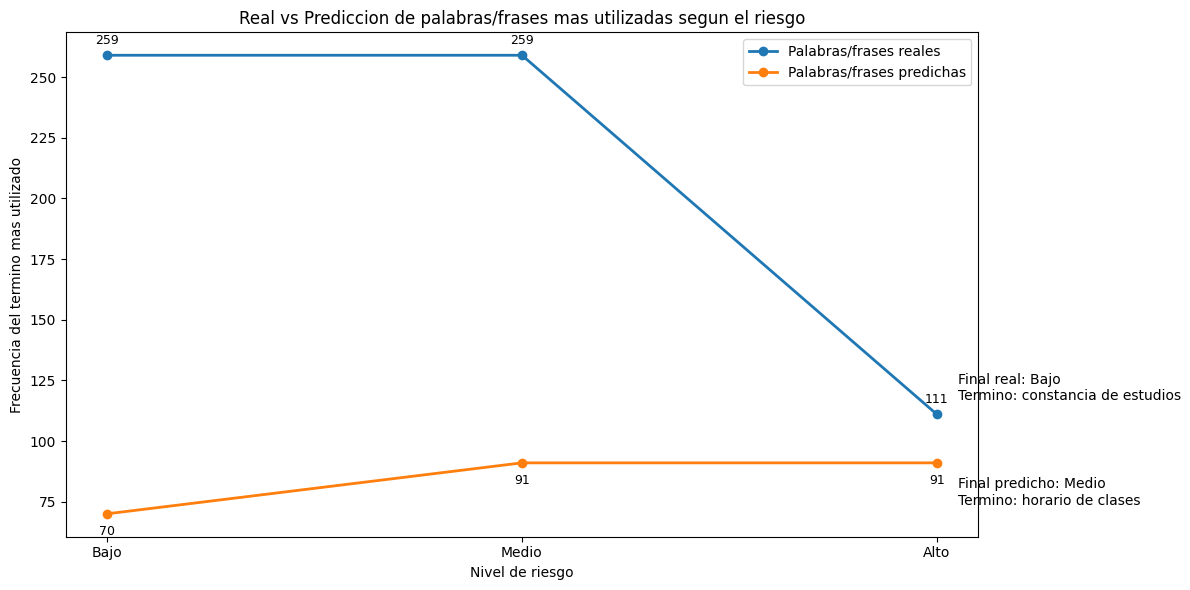

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

risk_order = ["Bajo", "Medio", "Alto"]

def top_term_by_risk(df, risk_col, term_col):
    rows = []

    for risk in risk_order:
        subset = df[df[risk_col] == risk]

        if subset.empty:
            rows.append({
                "risk_level": risk,
                "top_term": "Sin datos",
                "freq": 0
            })
        else:
            vc = subset[term_col].value_counts()
            rows.append({
                "risk_level": risk,
                "top_term": vc.index[0],
                "freq": vc.iloc[0]
            })

    return pd.DataFrame(rows)

real_terms = top_term_by_risk(df_matches, "risk", "matched_text")
pred_terms = top_term_by_risk(df_matches, "predicted_risk", "matched_text")

real_terms = real_terms.set_index("risk_level").reindex(risk_order)
pred_terms = pred_terms.set_index("risk_level").reindex(risk_order)

real_final_risk = real_terms["freq"].idxmax()
pred_final_risk = pred_terms["freq"].idxmax()

real_final_term = real_terms.loc[real_final_risk, "top_term"]
pred_final_term = pred_terms.loc[pred_final_risk, "top_term"]

x = np.arange(len(risk_order))

plt.figure(figsize=(12, 6))

plt.plot(x, real_terms["freq"].values, marker="o", linewidth=2, label="Palabras/frases reales")
plt.plot(x, pred_terms["freq"].values, marker="o", linewidth=2, label="Palabras/frases predichas")

for i, (freq, term) in enumerate(zip(real_terms["freq"].values, real_terms["top_term"].values)):
    plt.annotate(
        f"{int(freq)}",
        (x[i], freq),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9
    )

for i, (freq, term) in enumerate(zip(pred_terms["freq"].values, pred_terms["top_term"].values)):
    plt.annotate(
        f"{int(freq)}",
        (x[i], freq),
        textcoords="offset points",
        xytext=(0, -15),
        ha="center",
        fontsize=9
    )

plt.annotate(
    f"Final real: {real_final_risk}\nTermino: {real_final_term}",
    (x[-1], real_terms["freq"].iloc[-1]),
    textcoords="offset points",
    xytext=(15, 10),
    ha="left",
    fontsize=10
)

plt.annotate(
    f"Final predicho: {pred_final_risk}\nTermino: {pred_final_term}",
    (x[-1], pred_terms["freq"].iloc[-1]),
    textcoords="offset points",
    xytext=(15, -30),
    ha="left",
    fontsize=10
)

plt.title("Real vs Prediccion de palabras/frases mas utilizadas segun el riesgo")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Frecuencia del termino mas utilizado")
plt.xticks(x, risk_order)
plt.legend()
plt.tight_layout()
plt.show()

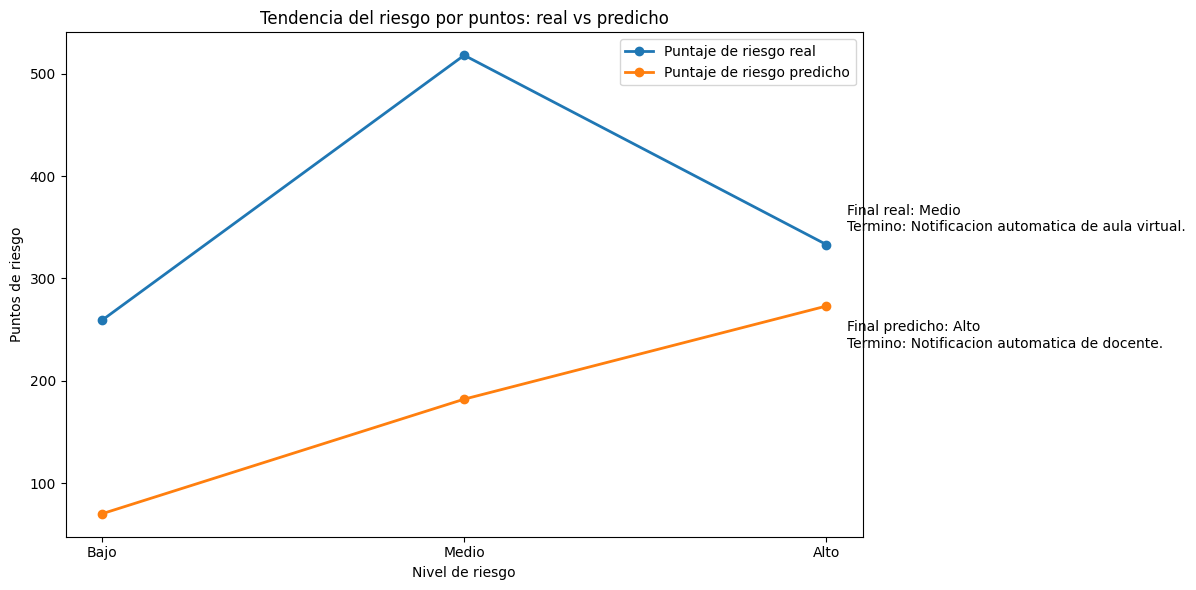

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

risk_order = ["Bajo", "Medio", "Alto"]

risk_points = {
    "Bajo": 1,
    "Medio": 2,
    "Alto": 3
    
}

df_matches["risk_points"] = df_matches["risk"].map(risk_points)
df_matches["predicted_risk_points"] = df_matches["predicted_risk"].map(risk_points)

def top_term_by_risk_points(df, risk_col, term_col, points_col):
    rows = []

    for risk in risk_order:
        subset = df[df[risk_col] == risk]

        if subset.empty:
            rows.append({
                "risk_level": risk,
                "top_term": "Sin datos",
                "total_points": 0
            })
        else:
            grouped = (
                subset.groupby(term_col)[points_col]
                .sum()
                .sort_values(ascending=False)
            )

            rows.append({
                "risk_level": risk,
                "top_term": grouped.index[0],
                "total_points": grouped.iloc[0]
            })

    return pd.DataFrame(rows)

real_terms = top_term_by_risk_points(
    df_matches,
    "risk",
    "matched_text",
    "risk_points"
)

pred_terms = top_term_by_risk_points(
    df_matches,
    "predicted_risk",
    "matched_text",
    "predicted_risk_points"
)

real_terms = real_terms.set_index("risk_level").reindex(risk_order)
pred_terms = pred_terms.set_index("risk_level").reindex(risk_order)

real_final_risk = real_terms["total_points"].idxmax()
pred_final_risk = pred_terms["total_points"].idxmax()

real_final_term = real_terms.loc[real_final_risk, "top_term"]
pred_final_term = pred_terms.loc[pred_final_risk, "top_term"]

x = np.arange(len(risk_order))

plt.figure(figsize=(12, 6))

plt.plot(
    x,
    real_terms["total_points"].values,
    marker="o",
    linewidth=2,
    label="Puntaje de riesgo real"
)

plt.plot(
    x,
    pred_terms["total_points"].values,
    marker="o",
    linewidth=2,
    label="Puntaje de riesgo predicho"
)

plt.annotate(
    f"Final real: {real_final_risk}\nTermino: {real_final_term}",
    (x[-1], real_terms["total_points"].iloc[-1]),
    textcoords="offset points",
    xytext=(15, 10),
    ha="left",
    fontsize=10
)

plt.annotate(
    f"Final predicho: {pred_final_risk}\nTermino: {pred_final_term}",
    (x[-1], pred_terms["total_points"].iloc[-1]),
    textcoords="offset points",
    xytext=(15, -30),
    ha="left",
    fontsize=10
)

plt.title("Tendencia del riesgo por puntos: real vs predicho")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Puntos de riesgo")
plt.xticks(x, risk_order)
plt.legend()
plt.tight_layout()
plt.show()

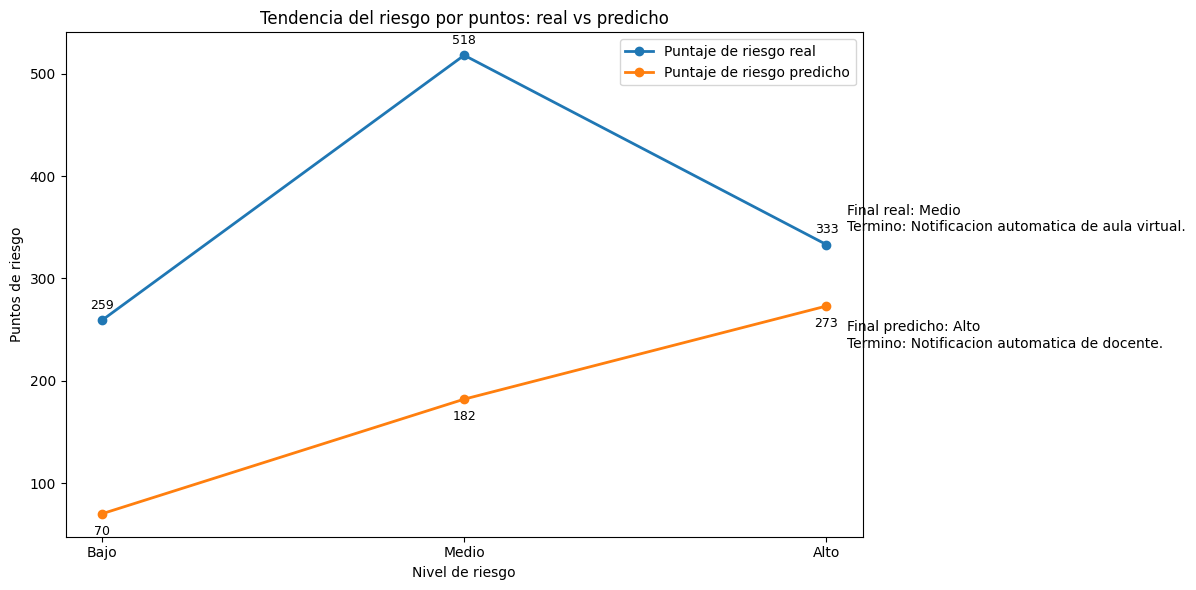

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

risk_order = ["Bajo", "Medio", "Alto"]

risk_points = {
    "Bajo": 1,
    "Medio": 2,
    "Alto": 3
}


df_matches["risk_points"] = df_matches["risk"].map(risk_points)
df_matches["predicted_risk_points"] = df_matches["predicted_risk"].map(risk_points)


def top_term_by_risk_points(df, risk_col, term_col, points_col):
    rows = []

    for risk in risk_order:
        subset = df[df[risk_col] == risk]

        if subset.empty:
            rows.append({
                "risk_level": risk,
                "top_term": "Sin datos",
                "total_points": 0
            })
        else:
            grouped = (
                subset.groupby(term_col)[points_col]
                .sum()
                .sort_values(ascending=False)
            )

            rows.append({
                "risk_level": risk,
                "top_term": grouped.index[0],
                "total_points": grouped.iloc[0]
            })

    return pd.DataFrame(rows)


real_terms = top_term_by_risk_points(
    df_matches,
    "risk",
    "matched_text",
    "risk_points"
)


pred_terms = top_term_by_risk_points(
    df_matches,
    "predicted_risk",
    "matched_text",
    "predicted_risk_points"
)

real_terms = real_terms.set_index("risk_level").reindex(risk_order)
pred_terms = pred_terms.set_index("risk_level").reindex(risk_order)


real_final_risk = real_terms["total_points"].idxmax()
pred_final_risk = pred_terms["total_points"].idxmax()

real_final_term = real_terms.loc[real_final_risk, "top_term"]
pred_final_term = pred_terms.loc[pred_final_risk, "top_term"]

x = np.arange(len(risk_order))


plt.figure(figsize=(12, 6))

plt.plot(
    x,
    real_terms["total_points"].values,
    marker="o",
    linewidth=2,
    label="Puntaje de riesgo real"
)

plt.plot(
    x,
    pred_terms["total_points"].values,
    marker="o",
    linewidth=2,
    label="Puntaje de riesgo predicho"
)


for i, y in enumerate(real_terms["total_points"].values):
    plt.annotate(
        f"{int(y)}",
        (x[i], y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9
    )

for i, y in enumerate(pred_terms["total_points"].values):
    plt.annotate(
        f"{int(y)}",
        (x[i], y),
        textcoords="offset points",
        xytext=(0, -15),
        ha="center",
        fontsize=9
    )


plt.annotate(
    f"Final real: {real_final_risk}\nTermino: {real_final_term}",
    (x[-1], real_terms["total_points"].iloc[-1]),
    textcoords="offset points",
    xytext=(15, 10),
    ha="left",
    fontsize=10
)

plt.annotate(
    f"Final predicho: {pred_final_risk}\nTermino: {pred_final_term}",
    (x[-1], pred_terms["total_points"].iloc[-1]),
    textcoords="offset points",
    xytext=(15, -30),
    ha="left",
    fontsize=10
)

plt.title("Tendencia del riesgo por puntos: real vs predicho")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Puntos de riesgo")
plt.xticks(x, risk_order)
plt.legend()
plt.tight_layout()
plt.show()

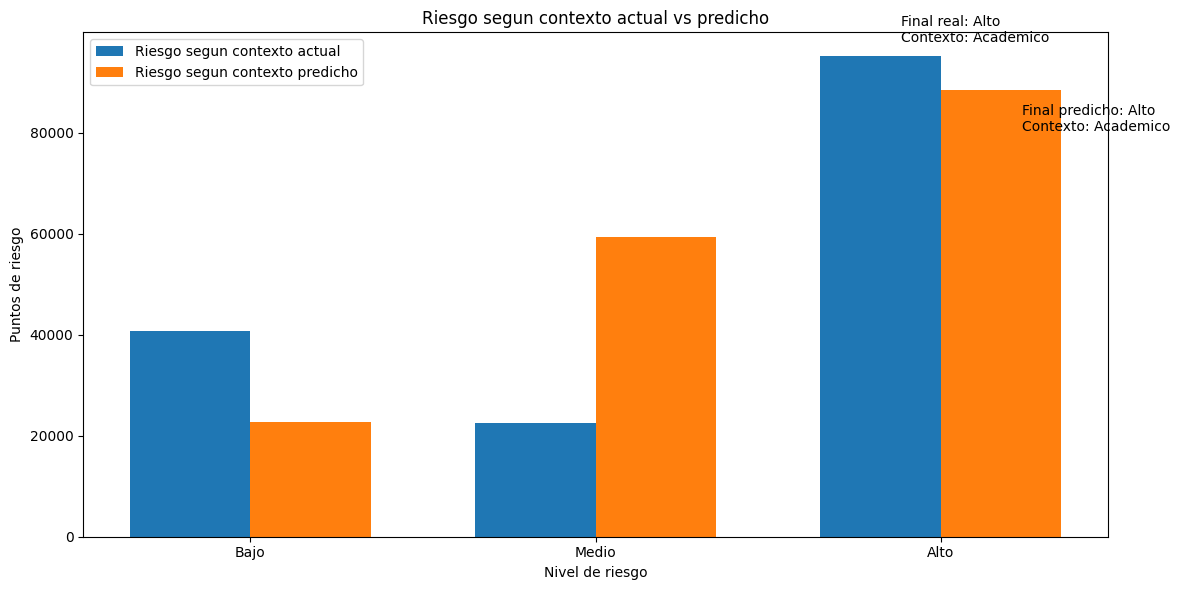

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


risk_order = ["Bajo", "Medio", "Alto"]

risk_points = {
    "Bajo": 1,
    "Medio": 2,
    "Alto": 3
}


df_matches["risk_points"] = df_matches["risk"].map(risk_points)
df_matches["predicted_risk_points"] = df_matches["predicted_risk"].map(risk_points)


def top_context_by_risk_points(df, risk_col, context_col, points_col):
    rows = []

    for risk in risk_order:
        subset = df[df[risk_col] == risk]

        if subset.empty:
            rows.append({
                "risk_level": risk,
                "top_context": "Sin datos",
                "total_points": 0
            })
        else:
            grouped = (
                subset.groupby(context_col)[points_col]
                .sum()
                .sort_values(ascending=False)
            )

            rows.append({
                "risk_level": risk,
                "top_context": grouped.index[0],
                "total_points": grouped.iloc[0]
            })

    return pd.DataFrame(rows)


real_contexts = top_context_by_risk_points(
    df_matches,
    "risk",
    "context",
    "risk_points"
)


pred_contexts = top_context_by_risk_points(
    df_matches,
    "predicted_risk",
    "context",
    "predicted_risk_points"
)

real_contexts = real_contexts.set_index("risk_level").reindex(risk_order)
pred_contexts = pred_contexts.set_index("risk_level").reindex(risk_order)

real_final_risk = real_contexts["total_points"].idxmax()
pred_final_risk = pred_contexts["total_points"].idxmax()

real_final_context = real_contexts.loc[real_final_risk, "top_context"]
pred_final_context = pred_contexts.loc[pred_final_risk, "top_context"]

x = np.arange(len(risk_order))
width = 0.35

plt.figure(figsize=(12, 6))

bars1 = plt.bar(
    x - width/2,
    real_contexts["total_points"].values,
    width,
    label="Riesgo segun contexto actual"
)

bars2 = plt.bar(
    x + width/2,
    pred_contexts["total_points"].values,
    width,
    label="Riesgo segun contexto predicho"
)

plt.annotate(
    f"Final real: {real_final_risk}\nContexto: {real_final_context}",
    (x[-1] - width/2, real_contexts["total_points"].iloc[-1]),
    textcoords="offset points",
    xytext=(15, 10),
    ha="left",
    fontsize=10
)

plt.annotate(
    f"Final predicho: {pred_final_risk}\nContexto: {pred_final_context}",
    (x[-1] + width/2, pred_contexts["total_points"].iloc[-1]),
    textcoords="offset points",
    xytext=(15, -30),
    ha="left",
    fontsize=10
)

plt.title("Riesgo segun contexto actual vs predicho")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Puntos de riesgo")
plt.xticks(x, risk_order)
plt.legend()
plt.tight_layout()
plt.show()

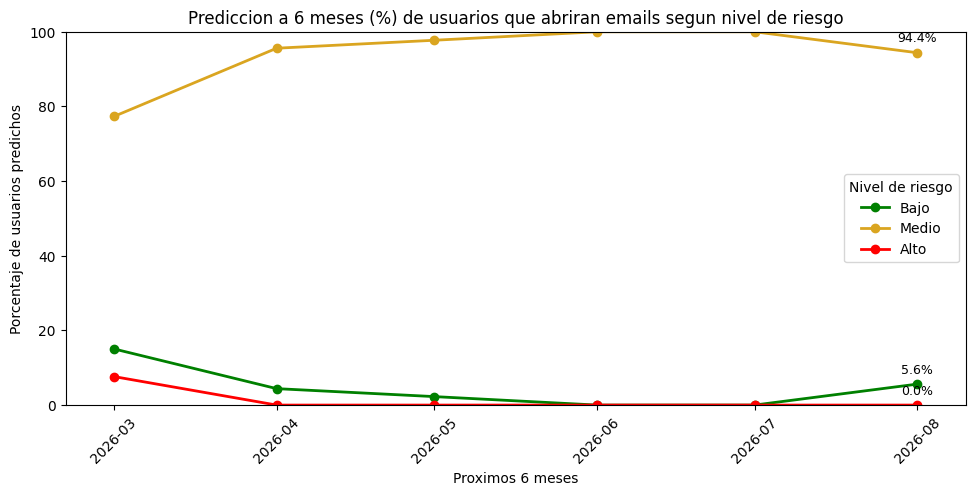

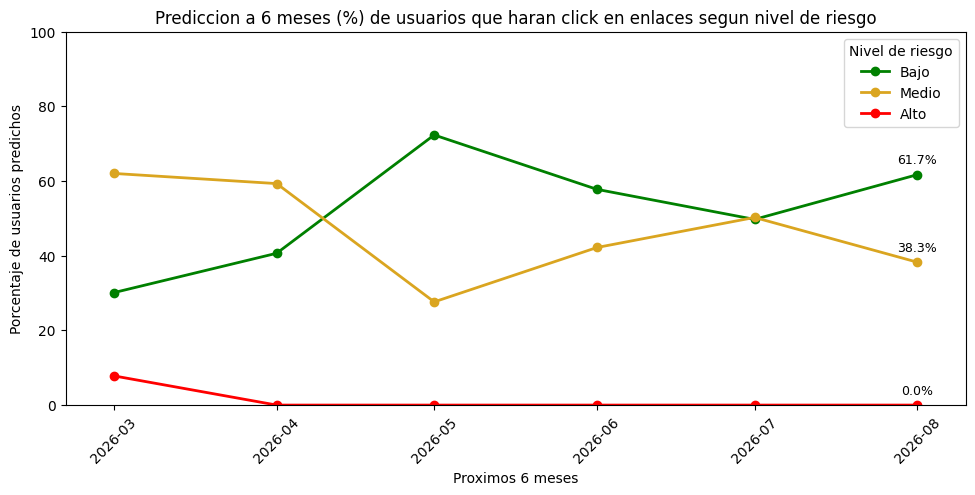

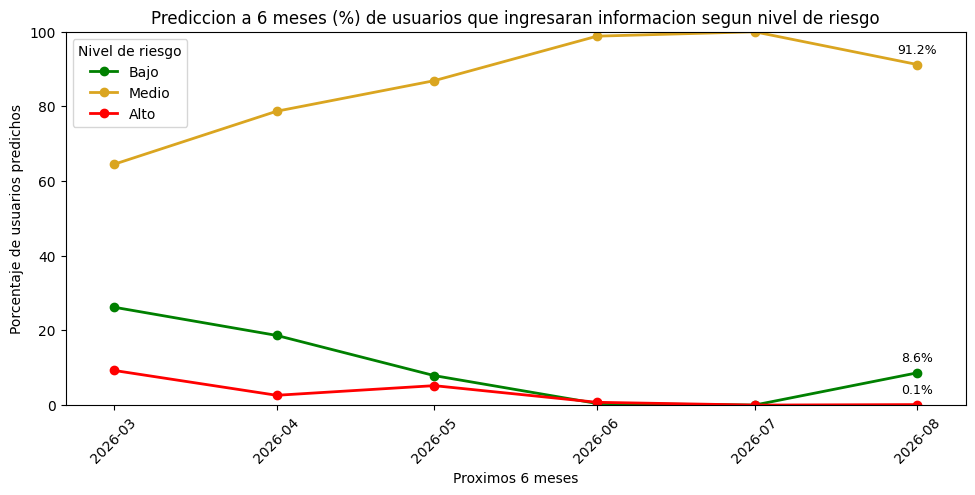

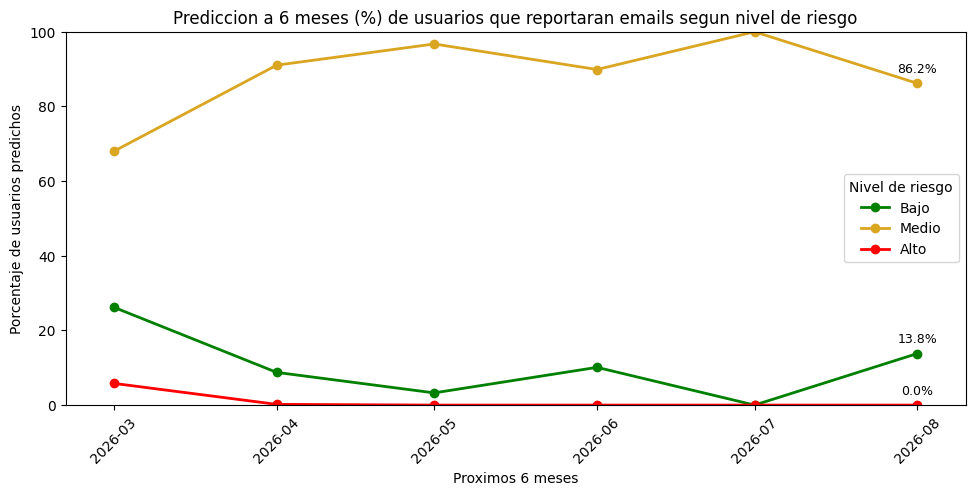

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df_pred_base = df_dash.copy()
df_pred_base["modified_date"] = pd.to_datetime(df_pred_base["modified_date"], errors="coerce")
df_pred_base = df_pred_base.dropna(subset=["modified_date"])

risk_order = ["Bajo", "Medio", "Alto"]
risk_colors = {
    "Bajo": "green",
    "Medio": "goldenrod",
    "Alto": "red"
}

def forecast_6_months_by_risk_pct(
    df,
    title,
    date_col="modified_date",
    risk_col="risk_level",
    user_col="user_id",
    status_col="result_status",
    target_status=None,
    reported_mode=False,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    if reported_mode:
        df_event = df[df["reported"] == 1].copy()
    else:
        df_event = df[df[status_col] == target_status].copy()

    if df_event.empty:
        print(f"No hay datos para: {title}")
        return

    df_event["month"] = df_event[date_col].dt.to_period("M").dt.to_timestamp()

    monthly_counts = (
        df_event.groupby(["month", risk_col])[user_col]
        .nunique()
        .reset_index(name="users")
    )

    full_months = pd.date_range(
        start=monthly_counts["month"].min(),
        end=monthly_counts["month"].max(),
        freq="MS"
    )

    future_months = pd.date_range(
        start=full_months.max() + pd.offsets.MonthBegin(1),
        periods=6,
        freq="MS"
    )

    pred_dict = {}

    for i, risk in enumerate(risk_order):
        subset = monthly_counts[monthly_counts[risk_col] == risk].copy()
        subset = subset[["month", "users"]]

        subset = (
            subset.set_index("month")
            .reindex(full_months, fill_value=0)
            .rename_axis("month")
            .reset_index()
        )

        series = subset["users"].astype(float).values

        if len(series) == 0:
            pred_dict[risk] = np.zeros(6)
            continue

        recent_window = min(6, len(series))
        recent = series[-recent_window:]

        if len(recent) >= 2:
            trend = np.mean(np.diff(recent))
        else:
            trend = 0.0

        level = recent.mean()


        seasonal_pattern = recent - recent.mean()


        residual_std = recent.std(ddof=1) if len(recent) > 1 else 0.0
        if np.isnan(residual_std):
            residual_std = 0.0

        y_pred = []
        current_level = level

        for step in range(6):
            seasonal_component = seasonal_pattern[step % len(seasonal_pattern)] if len(seasonal_pattern) > 0 else 0
            noise = rng.normal(0, residual_std * 0.35)

            next_value = current_level + trend + seasonal_component * 0.35 + noise
            next_value = max(0, next_value)

            y_pred.append(next_value)
            current_level = next_value

        pred_dict[risk] = np.array(y_pred)


    pred_df = pd.DataFrame(pred_dict, index=future_months)

    row_sums = pred_df.sum(axis=1).replace(0, np.nan)
    pred_pct = pred_df.div(row_sums, axis=0) * 100
    pred_pct = pred_pct.fillna(0)

    plt.figure(figsize=(10, 5.2))

    for risk in risk_order:
        y_pct = pred_pct[risk].values

        plt.plot(
            future_months,
            y_pct,
            marker="o",
            linewidth=2,
            label=risk,
            color=risk_colors[risk]
        )

        plt.annotate(
            f"{y_pct[-1]:.1f}%",
            (future_months[-1], y_pct[-1]),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=9
        )

    plt.title(title)
    plt.xlabel("Proximos 6 meses")
    plt.ylabel("Porcentaje de usuarios predichos")
    plt.xticks(rotation=45)
    plt.ylim(0, 100)

    plt.margins(x=0.06, y=0.12)

    plt.legend(title="Nivel de riesgo")
    plt.tight_layout(pad=1.6)
    plt.show()



forecast_6_months_by_risk_pct(
    df=df_pred_base,
    title="Prediccion a 6 meses (%) de usuarios que abriran emails segun nivel de riesgo",
    target_status="Email Opened",
    random_state=10
)

forecast_6_months_by_risk_pct(
    df=df_pred_base,
    title="Prediccion a 6 meses (%) de usuarios que haran click en enlaces segun nivel de riesgo",
    target_status="Clicked Link",
    random_state=20
)


forecast_6_months_by_risk_pct(
    df=df_pred_base,
    title="Prediccion a 6 meses (%) de usuarios que ingresaran informacion segun nivel de riesgo",
    target_status="Submitted Data",
    random_state=30
)


forecast_6_months_by_risk_pct(
    df=df_pred_base,
    title="Prediccion a 6 meses (%) de usuarios que reportaran emails segun nivel de riesgo",
    reported_mode=True,
    random_state=40
)